<center> <font size = 10> Capstone - Customer Churn Prediction </center> </font>

#**Understanding the Business Problem**

**Business Context:**

AlphaCom, a leading telecommunications provider, has recently experienced a concerning rise in customer churn despite offering competitive services and a wide product portfolio. This increase is directly impacting revenue and undermining brand reputation in an intensely competitive market. Traditional retention strategies have proven inadequate because customer churn is influenced by a complex mix of factors, including service usage, billing preferences, contract types, and demographics. Without clear insights into these patterns, the company is left reacting to churn instead of preventing it.





**Objective:**



As a data scientist at AlphaCom, you are tasked with developing a predictive model to identify customers at high risk of churn and uncover the key factors driving their decisions. Solving this problem will enable the company to proactively design targeted retention strategies, reduce churn-related losses, and improve customer lifetime value, ultimately safeguarding revenue and strengthening AlphaCom’s competitive position.





**Data Description:**


The data contains different attributes related to churn. The detailed data dictionary is given below:

**Gender:** The customer’s gender (e.g., Male or Female). This demographic feature may correlate with customer behavior.</br>
**SeniorCitizen:** A binary indicator (if included) that identifies whether the customer is a senior citizen (commonly 1 for senior, 0 for non-senior). Senior status can influence service preferences and retention strategies.</br>
**Partner:** Indicates whether the customer has a partner. This factor can affect customer loyalty and service usage patterns.</br>
**Dependents:** Specifies whether the customer has dependents. This information can provide context on the customer’s household and influence their service needs.</br>
**Tenure:** The number of months the customer has been with the company. Longer tenure may indicate higher loyalty, while shorter tenure could be a churn risk indicator.</br>
**PhoneService:** Denotes whether the customer subscribes to telephone services. This binary feature (Yes/No) helps understand service adoption.</br>
**MultipleLines:** Indicates if the customer has multiple phone lines. This feature can provide insight into customer behavior and service complexity.</br>
**InternetService:** Describes the type of internet service the customer uses (e.g., DSL, Fiber optic, or None). The type of internet service can be a critical factor in churn analysis.</br>
**OnlineSecurity:** Shows whether the customer subscribes to online security services. This value (Yes/No) may influence customer satisfaction and retention.</br>
**OnlineBackup:** Indicates if the customer has an online backup service. Similar to online security, this can be a part of the overall service bundle affecting churn.</br>
**DeviceProtection:** Specifies whether the customer is enrolled in a device protection plan, providing an added layer of service value.</br>
**TechSupport:** Denotes if the customer subscribes to technical support services. Access to tech support can improve customer experience and reduce churn.</br>
**StreamingTV:** Indicates whether the customer subscribes to a streaming TV service. Media consumption patterns can be a differentiator in customer preferences.</br>
**StreamingMovies:** Specifies if the customer subscribes to a streaming movies service. This, combined with other services, can highlight trends in customer behavior.</br>
**Contract:** Describes the type of contract the customer holds (e.g., month-to-month, one-year, or two-year). Contract type is a strong indicator of churn risk—shorter contracts are often associated with higher churn.</br>
**PaperlessBilling:** Indicates whether the customer is enrolled in paperless billing. This operational feature can sometimes correlate with customer engagement levels.</br>
**PaymentMethod:** Details the payment method used by the customer (e.g., electronic check, mailed check, bank transfer, or credit card). Payment methods can affect both churn and overall customer satisfaction.</br>
**MonthlyCharges:** The monthly amount in  USD' charged to the customer. Higher charges might increase the likelihood of churn if customers perceive the cost as too high for the value provided.</br>
**TotalCharges:** The cumulative amount in USD charged over the customer’s tenure. This helps in understanding the long-term value of each customer and can be a predictor of churn.</br>
**Churn:** The target variable indicating whether the customer has left (typically denoted as “Yes” or “No”). This is the primary outcome you aim to predict with your machine learning model.



# **Installing and Importing Necessary Libraries and functions**

In [ ]:
# this will help in making the Python code more structured automatically (help adhere to good coding practices)
# %load_ext nb_black

import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
#from sklearn import tree

# To tune different models
#from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python/customer_churn.csv')

# **Data Overview**

This gives us a basic and important information of our dataset.  The initial
steps to understand a dataset is to:

* Observe the first few rows of the dataset to check whether the
dataset is loaded properly or not.
* Get information about the rows and columns in the dataset.
* Find out the data types and non-null value counts of the column .
* Check the statistical summary of the dataset to get an overview of
the numerical columns of the data.

## Displaying the first few rows of the dataset

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.00000,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85,$29.85,No
1,Male,0,No,No,34.00000,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,$56.95,$1889.5,NO
2,Male,0,No,No,2.00000,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85,$108.15,YES
3,Male,0,No,No,45.00000,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,bank transfer (automatic),$42.3,$1840.75,No
4,Female,0,No,No,2.00000,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,$70.7,$nan,yes


*  The dataset contains multiple service-related features that are likely to play an important role in predicting customer churn.
*  Contract types vary between Month-to-month and One year, which may influence customer retention behavior.
*  Customers use different internet services including DSL and Fiber optic, indicating varied service plans among customers.
*  The dataset contains customer demographic information, service subscription details, billing information, and contract-related features that can help analyze customer churn behavior.

## Checking the shape of the dataset

In [ ]:
df.shape

(12055, 20)

The dataset consists of 12055 rows and 20 columns.

## Checking the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  int64  
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

*  The dataset consists of 18 object data type and 2 numeric data type.
*  The target variable is `Churn` which is of object data type.

Since the columns `MonthlyCharges` and `TotalCharges` had currency symbols such as $ and £, I removed those characters and converted the values into a numeric data type to ensure proper analysis and modeling.

In [ ]:
# Fix TotalCharges
df['TotalCharges'] = (
    df['TotalCharges']
    .astype(str)
    .str.replace(r'[\$£,]', '', regex=True)  # str.replace + added £
    .str.replace('nan', '')                   # fix string 'nan'
    .replace('', np.nan)                      # convert empty to NaN
)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fix MonthlyCharges
df['MonthlyCharges'] = (
    df['MonthlyCharges']
    .astype(str)
    .str.replace(r'[\$£,]', '', regex=True)  # str.replace + added £
    .str.replace('nan', '')                   # fix string 'nan'
    .replace('', np.nan)                      # convert empty to NaN
)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

# Verify - check no £ remains
print("\nMonthlyCharges sample:")
print(df['MonthlyCharges'].head(10))
print("\nTotalCharges sample:")
print(df['TotalCharges'].head(10))



MonthlyCharges sample:
0    29.85000
1    56.95000
2    53.85000
3    42.30000
4    70.70000
5    99.65000
6    89.10000
7    29.75000
8   104.80000
9    56.15000
Name: MonthlyCharges, dtype: float64

TotalCharges sample:
0     29.85000
1   1889.50000
2    108.15000
3   1840.75000
4          NaN
5    820.50000
6   1949.40000
7    301.90000
8   3046.05000
9   3487.95000
Name: TotalCharges, dtype: float64


We have convered both the columns to numeric data type.

## Statistical summary of the dataset

In [ ]:
display(df.describe().T.round(2).style.format("{:.2f}"))

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,12055.00,0.12,0.32,0.00,0.00,0.00,0.00,1.00
tenure,11451.00,31.24,25.03,-3.00,6.00,28.00,54.00,74.00
MonthlyCharges,11754.00,64.37,30.33,15.29,30.31,71.35,89.38,121.67
TotalCharges,10850.00,2291.76,2277.46,-197.00,383.65,1328.75,3959.08,9039.92


*  `SeniorCitizen`: The mean is 0.117, meaning only about 12% of your customers are seniors.
*  `MonthlyCharges`: Ranges from $15.29 to $121.67. This variety suggests different service tiers (DSL vs. Fiber) which likely impacts churn.
*  There are negative values in the column `tenure` and `TotalCharges` which is an error.
*  There are outliers in `TotalCharges`.

Lets find out the no of rows where we have negative values in the columns.

In [ ]:
# Check how many negative values exist
print((df['tenure'] < 0).sum())
print((df['TotalCharges'] < 0).sum())

127
147


*  There are 127 rows in `tenure` column with negative values.
*  There are 147 rows in `TotalCharges` column with negative values.

In [ ]:
df['tenure'] = df['tenure'].where(df['tenure'] >= 0, np.nan)
df['TotalCharges'] = df['TotalCharges'].where(df['TotalCharges'] >= 0, np.nan)

In [ ]:
# Convert zero values to NaN
df['tenure'] = df['tenure'].replace(0, np.nan)
df['TotalCharges'] = df['TotalCharges'].replace(0, np.nan)

We'll convert the negative values and 0 to nan and then perform imputation after splitting the data into train and test.

## Duplicate Check Before Data Cleaning

In [ ]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
df = df.reset_index(drop=True)

Duplicates before: 2


## Categorical Data Check

Let's go ahead and check for data anomalies in the categorical variables

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: gender
gender
Male      6710
Female    5343
Name: count, dtype: int64

Column: Partner
Partner
No     6988
Yes    5065
Name: count, dtype: int64

Column: Dependents
Dependents
No     8845
Yes    3208
Name: count, dtype: int64

Column: PhoneService
PhoneService
Yes    10745
No      1308
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
Yes                 5609
No                  5155
No phone service    1289
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    4877
DSL            4350
No             2826
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
No                     6311
Yes                    2924
No internet service    2818
Name: count, dtype: int64

Column: OnlineBackup
OnlineBackup
No                     5981
Yes                    3271
No internet service    2801
Name: count, dtype: int64

Column: DeviceProtection
DeviceProtection
Yes                    4634
No                     4591
No internet service 

Same payment category exists in multiple formats due to inconsistent capitalisation and leading/trailing spaces. e.g., "Electronic check", "ELECTRONIC CHECK", "  Electronic check" are all the same category.

In [ ]:
df['PaymentMethod'] = df['PaymentMethod'].str.strip().str.lower().str.capitalize()

# Verify
print(df['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             4145
Credit card (automatic)      2929
Mailed check                 2584
Bank transfer (automatic)    2395
Name: count, dtype: int64


 The target variable has the same two categories (Yes and No) stored in multiple formats due to inconsistent capitalisation and leading/trailing spaces. e.g., "Yes", "YES", "yes", "  Yes" are all the same category.

In [ ]:
df['Churn'] = df['Churn'].str.strip().str.lower().str.capitalize()

# Verify
print(df['Churn'].value_counts())

Churn
No     8649
Yes    3404
Name: count, dtype: int64


The data inconsistencies in the columns `Churn` and `PaymentMethod` has been fixed.

In [ ]:
print(pd.crosstab(df['PhoneService'], df['MultipleLines']))

MultipleLines    No  No phone service   Yes
PhoneService                               
No              103              1137    68
Yes            5052               152  5541


In [ ]:
internet_dependent_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_dependent_cols:
    print(f"\n--- Logical Check: InternetService vs {col} ---")
    print(pd.crosstab(df['InternetService'], df[col], margins=True))



--- Logical Check: InternetService vs OnlineSecurity ---
OnlineSecurity     No  No internet service   Yes    All
InternetService                                        
DSL              2555                   19  1776   4350
Fiber optic      3740                    7  1130   4877
No                 16                 2792    18   2826
All              6311                 2818  2924  12053

--- Logical Check: InternetService vs OnlineBackup ---
OnlineBackup       No  No internet service   Yes    All
InternetService                                        
DSL              2852                   12  1486   4350
Fiber optic      3088                    7  1782   4877
No                 41                 2782     3   2826
All              5981                 2801  3271  12053

--- Logical Check: InternetService vs DeviceProtection ---
DeviceProtection    No  No internet service   Yes    All
InternetService                                         
DSL               1936                  

*  The dataset was checked for logical inconsistencies by comparing internet-dependent service variables with the InternetService feature. Instances where a customer was marked as having “No internet service” despite having an active internet connection were identified and corrected.
* The dataset was also checked for logical inconsistencies by comparing multiplelines variable which is dependent on phone service. Instances where a customer was marked as having 'no phone service' despite having a phone service.

In [ ]:
# Fix Internet Dependencies
for col in internet_dependent_cols:
    df.loc[(df['InternetService'] != 'No') & (df[col] == 'No internet service'), col] = 'No'
    df.loc[df['InternetService'] == 'No', col] = 'No'
    df[col] = df[col].replace('No internet service', 'No')

# Fix Phone Dependents
df.loc[(df['PhoneService'] == 'Yes') & (df['MultipleLines'] == 'No phone service'), 'MultipleLines'] = 'No'
df.loc[df['PhoneService'] == 'No', 'MultipleLines'] = 'No'
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Verify Results — All 6 internet dependent columns
print("=" * 50)
print("Verification: Internet vs All Dependent Columns")
print("=" * 50)
for col in internet_dependent_cols:
    print(f"\nInternet vs {col}:")
    print(pd.crosstab(df['InternetService'], df[col]))

# Verify MultipleLines
print("\n" + "=" * 50)
print("Verification: PhoneService vs MultipleLines")
print("=" * 50)
print(pd.crosstab(df['PhoneService'], df['MultipleLines']))

Verification: Internet vs All Dependent Columns

Internet vs OnlineSecurity:
OnlineSecurity     No   Yes
InternetService            
DSL              2574  1776
Fiber optic      3747  1130
No               2826     0

Internet vs OnlineBackup:
OnlineBackup       No   Yes
InternetService            
DSL              2864  1486
Fiber optic      3095  1782
No               2826     0

Internet vs DeviceProtection:
DeviceProtection    No   Yes
InternetService             
DSL               1960  2390
Fiber optic       2651  2226
No                2826     0

Internet vs TechSupport:
TechSupport        No   Yes
InternetService            
DSL              2545  1805
Fiber optic      3689  1188
No               2826     0

Internet vs StreamingTV:
StreamingTV        No   Yes
InternetService            
DSL              2723  1627
Fiber optic      2281  2596
No               2826     0

Internet vs StreamingMovies:
StreamingMovies    No   Yes
InternetService            
DSL              2684 

All the data errors and inconsistencies are corrected.

## Duplicate Check After Data Cleaning

In [ ]:
print("Duplicates after cleaning:", df.duplicated().sum())  # 25
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Final shape:", df.shape)


Duplicates after cleaning: 25
Final shape: (12028, 20)


All the duplicate values have been dropped.

# **Exploratory Data Analysis**

## Univariate Analysis - Numerical Variables

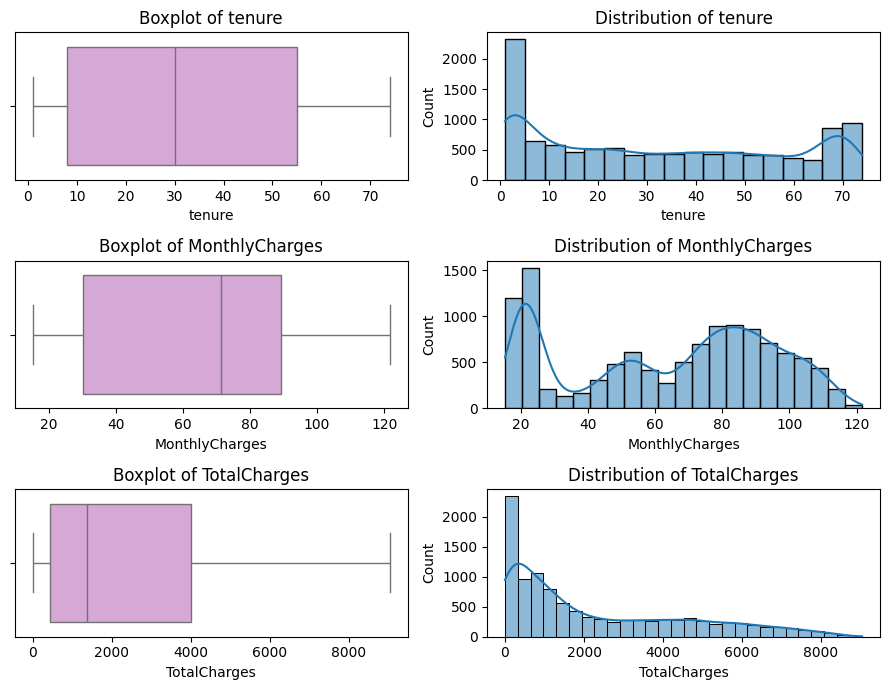

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(9,7)
)

for i, col in enumerate(num_cols):

    # Boxplot
    sns.boxplot(
        x=df[col],
        ax=axes[i, 0],
        color='plum'
    )

    axes[i, 0].set_title(f'Boxplot of {col}')

    # Histogram
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Insights:**
*  tenure shows a slight right-skew, indicating more customers are in early tenure periods.
*  MonthlyCharges displays a multipeak pattern, suggesting different customer pricing tiers.
*  TotalCharges is heavily right-skewed, with most customers having lower total spending.
*  Mild outliers are present in TotalCharges, likely representing long-term high-value customers.

## Univariate Analysis - Categorical Variables

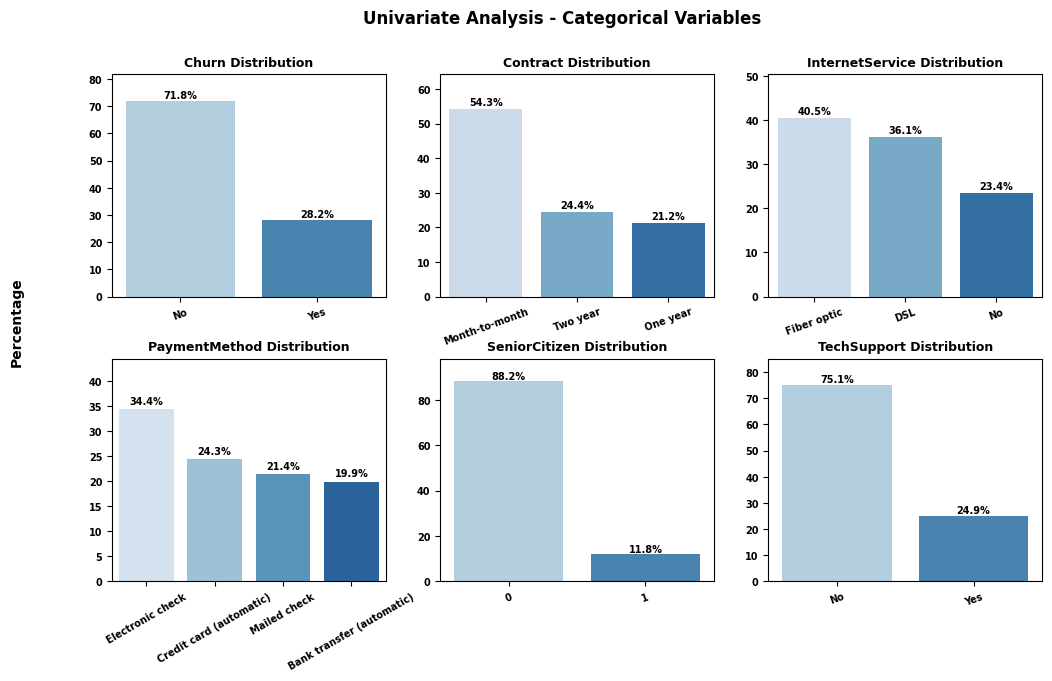

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = [
    'Churn',
    'Contract',
    'InternetService',
    'PaymentMethod',
    'SeniorCitizen',
    'TechSupport'
]

# Smaller font for compact report visuals
plt.rcParams.update({'font.size': 7})

# Create subplot grid
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 6.5)
)

# Flatten axes for looping
axes = axes.flatten()

# Loop through categorical columns
for i, col in enumerate(cat_cols):

    # Calculate percentages
    perc = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
    )

    # Create barplot
    sns.barplot(
        x=perc.index,
        y=perc.values,
        ax=axes[i],
        palette='Blues'
    )

    # Titles
    axes[i].set_title(
    f'{col} Distribution',
    fontsize=9,
    fontweight='bold'
)

    # Remove repeated axis labels
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # Rotate x labels
    if col == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=30)
    else:
        axes[i].tick_params(axis='x', rotation=20)

    # Set x-axis tick label fontweight to bold
    for label in axes[i].get_xticklabels():
        label.set_fontweight('bold')

    # Set y-axis tick label fontweight to bold
    for label in axes[i].get_yticklabels():
        label.set_fontweight('bold')

    # Add space above bars
    axes[i].set_ylim(0, max(perc.values) + 10)

    # Add percentage labels
    for j, v in enumerate(perc.values):

        axes[i].text(
            j,
            v + 1,
            f'{v:.1f}%',
            ha='center',
            fontweight='bold',
            fontsize=7
        )

# Main title
fig.suptitle(
    'Univariate Analysis - Categorical Variables',
    fontsize=12,
    fontweight='bold'
)

# Shared y-axis label
fig.text(
    0.04,
    0.5,
    'Percentage',
    va='center',
    rotation='vertical',
    fontsize=10,
    fontweight='bold'
)

# Adjust subplot spacing
plt.subplots_adjust(
    hspace=0.28,
    wspace=0.20,
    top=0.88,
    bottom=0.10
)
plt.show()


**Insights:**
*  Most customers are non-churners (71.8%), indicating class imbalance in the target variable.
*  Month-to-month contracts are the most common contract type among customers.
*  Fiber optic is the most widely used internet service.
*  Electronic check is the most preferred payment method.
*  Senior citizens represent a smaller portion of the customer base.
*  Most customers do not subscribe to TechSupport services.

## Bivariate analysis - Numerical Variables vs churn

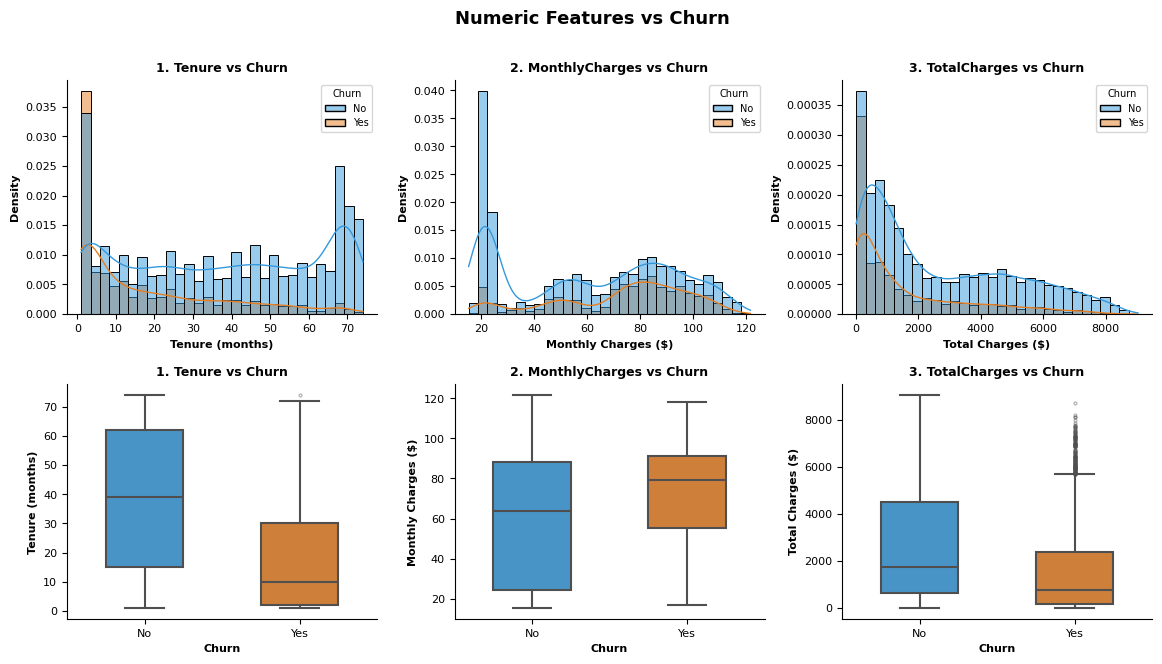

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Numeric Features vs Churn', fontsize=13, fontweight='bold')

palette = {'No': '#3498db', 'Yes': '#e67e22'}

numeric_features = [
    ('tenure',         'Tenure (months)',     '1. Tenure vs Churn'),
    ('MonthlyCharges', 'Monthly Charges ($)', '2. MonthlyCharges vs Churn'),
    ('TotalCharges',   'Total Charges ($)',   '3. TotalCharges vs Churn'),
]

for i, (col, xlabel, title) in enumerate(numeric_features):

    # ── Row 1: Histplot ──────────────────────────────────────────────
    sns.histplot(data=df, x=col, hue='Churn',
                 bins=30, stat='density',
                 alpha=0.5, kde=True,
                 line_kws={'linewidth':1},
                 palette=palette, ax=axes[0, i])
    axes[0, i].set_title(title, fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel(xlabel, fontsize=8, fontweight='bold')
    axes[0, i].set_ylabel('Density', fontsize=8, fontweight='bold')
    axes[0, i].tick_params(axis='both', labelsize=8)
    axes[0, i].spines['top'].set_visible(False)
    axes[0, i].spines['right'].set_visible(False)

    # ── Row 2: Boxplot ───────────────────────────────────────────────
    sns.boxplot(data=df, x='Churn', y=col,
                palette=palette,
                width=0.5, linewidth=1.5,
                flierprops=dict(marker='o', markersize=2, alpha=0.4),
                ax=axes[1, i])
    axes[1, i].set_title(title, fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('Churn', fontsize=8, fontweight='bold')
    axes[1, i].set_ylabel(xlabel, fontsize=8, fontweight='bold')
    axes[1, i].tick_params(axis='both', labelsize=8)
    axes[1, i].spines['top'].set_visible(False)
    axes[1, i].spines['right'].set_visible(False)

plt.subplots_adjust(
    hspace=0.30,
    wspace=0.25,
    top=0.88
)
plt.savefig('numeric_vs_churn_combined.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

*  Customers with lower tenure are more likely to churn, while long-tenure customers tend to stay.
*  Churned customers generally have higher MonthlyCharges compared to non-churned customers.
*  Customers with lower TotalCharges show higher churn, indicating early-stage customer exits.
*  TotalCharges displays a strong right-skew with a few high-value long-term customers.
*  MonthlyCharges and TotalCharges show noticeable distribution differences between churn groups.

## Bivariate analysis - Categorical Variables vs churn

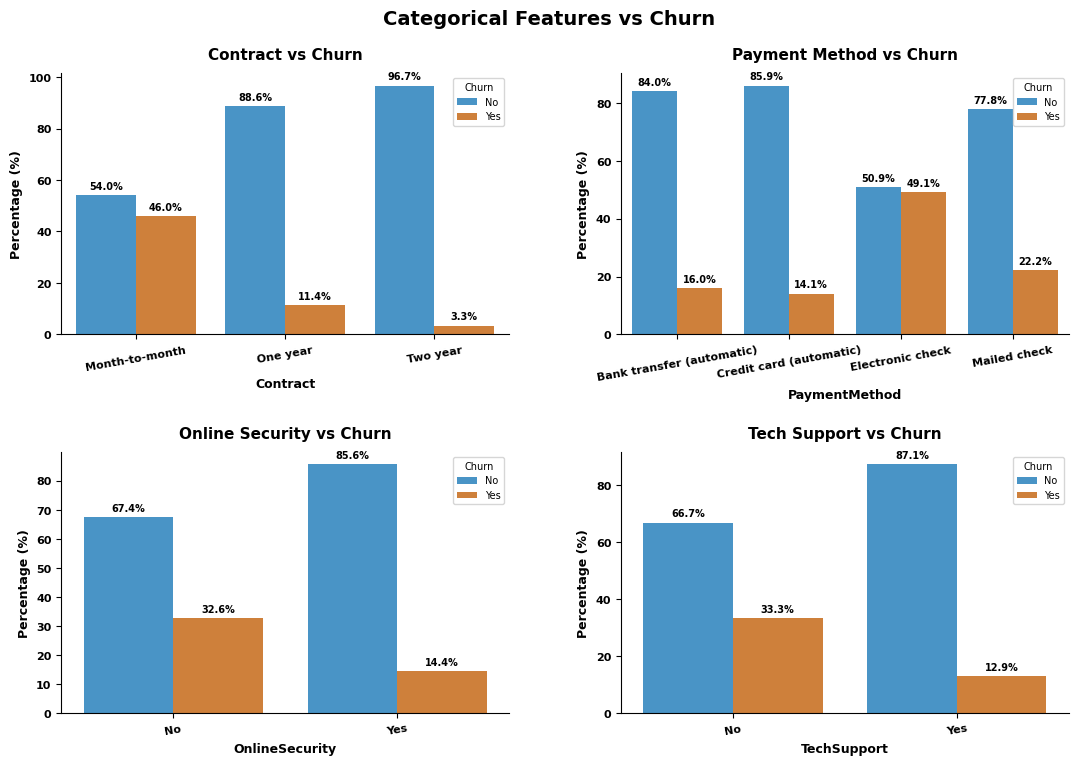

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Important categorical features
selected_features = [
    'Contract',
    'PaymentMethod',
    'OnlineSecurity',
    'TechSupport'
]

titles = [
    'Contract vs Churn',
    'Payment Method vs Churn',
    'Online Security vs Churn',
    'Tech Support vs Churn'
]

# Create subplot layout
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8)
)

axes = axes.flatten()

# Color palette
palette = {'No': '#3498db', 'Yes': '#e67e22'}

# Loop through features
for i, col in enumerate(selected_features):

    # Create percentage dataframe
    temp = (
        df.groupby(col)['Churn']
        .value_counts(normalize=True)
        .mul(100)
        .rename('Percentage')
        .reset_index()
    )

    # Plot
    sns.barplot(
        data=temp,
        x=col,
        y='Percentage',
        hue='Churn',
        palette=palette,
        ax=axes[i]
    )

    # Titles
    axes[i].set_title(
        titles[i],
        fontsize=11,
        fontweight='bold',
        pad=10
    )

    # Axis labels
    axes[i].set_xlabel(
        col,
        fontsize=9,
        fontweight='bold'
    )

    axes[i].set_ylabel(
        'Percentage (%)',
        fontsize=9,
        fontweight='bold'
    )

    # Tick formatting
    axes[i].tick_params(
        axis='x',
        rotation=10,
        labelsize=8
    )

    axes[i].tick_params(
        axis='y',
        labelsize=8
    )

    # Make tick labels bold
    for label in axes[i].get_xticklabels():
        label.set_fontweight('bold')

    for label in axes[i].get_yticklabels():
        label.set_fontweight('bold')

    # Add percentage labels
    for p in axes[i].patches:

        height = p.get_height()

        if height > 0:

            axes[i].annotate(
                f'{height:.1f}%',
                (
                    p.get_x() + p.get_width() / 2.,
                    height
                ),
                ha='center',
                va='bottom',
                fontsize=7,
                fontweight='bold',
                xytext=(0, 3),
                textcoords='offset points'
            )

    # Clean borders
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Main title
fig.suptitle(
    'Categorical Features vs Churn',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

# Adjust spacing properly
plt.subplots_adjust(
    hspace=0.45,
    wspace=0.25,
    top=0.90,
    bottom=0.10
)

# Save figure
plt.savefig(
    'categorical_vs_churn_main.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Insights:**
*  Month-to-month customers show the highest churn, while long-term contracts have much lower churn rates.
*  Customers using electronic check have noticeably higher churn compared to other payment methods.
*  Lack of OnlineSecurity and TechSupport is strongly associated with higher churn.

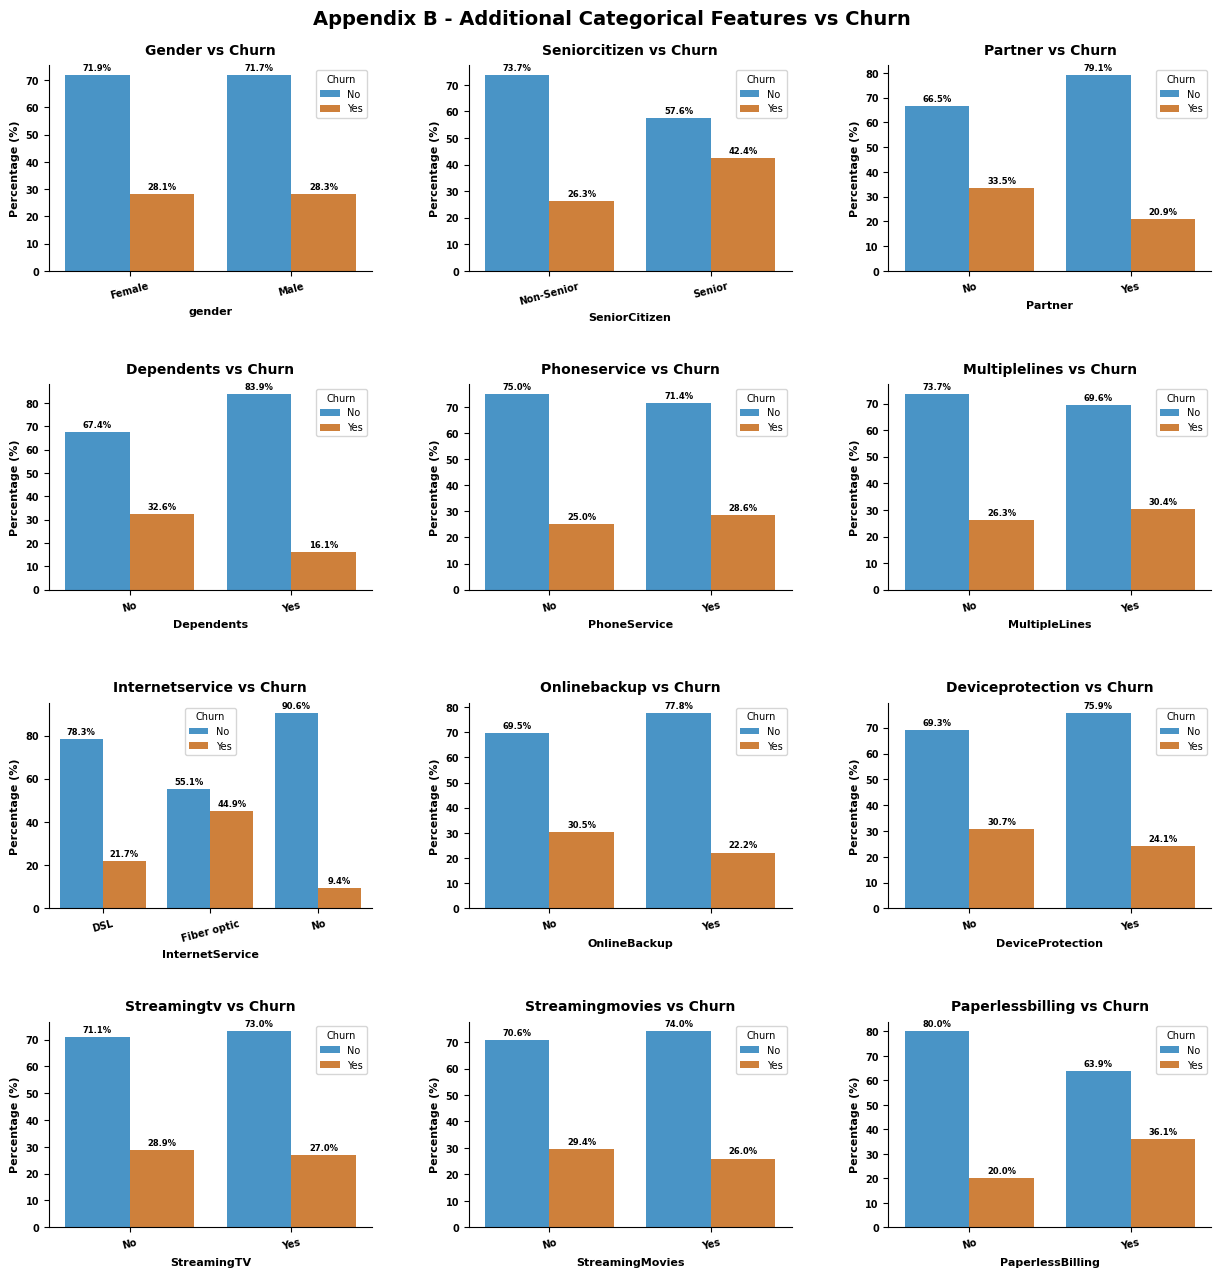

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remaining categorical variables for Appendix
appendix_features = [

    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineBackup',
    'DeviceProtection',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]

# Create subplot layout
fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 14)
)

axes = axes.flatten()

# Color palette
palette = {'No': '#3498db', 'Yes': '#e67e22'}

# Loop through features
for i, col in enumerate(appendix_features):

    # Create percentage dataframe
    temp = (
        df.groupby(col)['Churn']
        .value_counts(normalize=True)
        .mul(100)
        .rename('Percentage')
        .reset_index()
    )
    # Conditional data transformation (ONLY for SeniorCitizen)
    if col == 'SeniorCitizen':
        temp[col] = temp[col].replace({
            0: 'Non-Senior',
            1: 'Senior'
        })

    # Plot for all features
    sns.barplot(
        data=temp,
        x=col,
        y='Percentage',
        hue='Churn',
        palette=palette,
        ax=axes[i]
    )

    # Titles for all features
    title_col = col.replace('_', ' ').title()
    axes[i].set_title(
        f'{title_col} vs Churn',
        fontsize=10,
        fontweight='bold',
        pad=8
    )

    # Axis labels for all features
    axes[i].set_xlabel(
        col,
        fontsize=8,
        fontweight='bold'
    )

    axes[i].set_ylabel(
        'Percentage (%)',
        fontsize=8,
        fontweight='bold'
    )

    # Tick formatting for all features
    axes[i].tick_params(
        axis='x',
        rotation=15,
        labelsize=7
    )

    axes[i].tick_params(
        axis='y',
        labelsize=7
    )

    # Bold tick labels for all features
    for label in axes[i].get_xticklabels():
        label.set_fontweight('bold')

    for label in axes[i].get_yticklabels():
        label.set_fontweight('bold')

    # Add percentage labels for all features
    for p in axes[i].patches:

        height = p.get_height()

        if height > 0:

            axes[i].annotate(
                f'{height:.1f}%',
                (
                    p.get_x() + p.get_width() / 2.,
                    height
                ),
                ha='center',
                va='bottom',
                fontsize=6,
                fontweight='bold',
                xytext=(0, 2),
                textcoords='offset points'
            )

    # Remove top/right borders for all features
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Remove unused subplot spaces (if any)
for j in range(len(appendix_features), len(axes)):
    fig.delaxes(axes[j])

# Main title
fig.suptitle(
    'Appendix B - Additional Categorical Features vs Churn',
    fontsize=14,
    fontweight='bold',
    y=0.92
)

# Adjust spacing
plt.subplots_adjust(
    hspace=0.55,
    wspace=0.30,
    top=0.88,
    bottom=0.05
)

# Save figure
plt.savefig(
    'appendix_categorical_vs_churn.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Multivariate analysis

###Heatmap

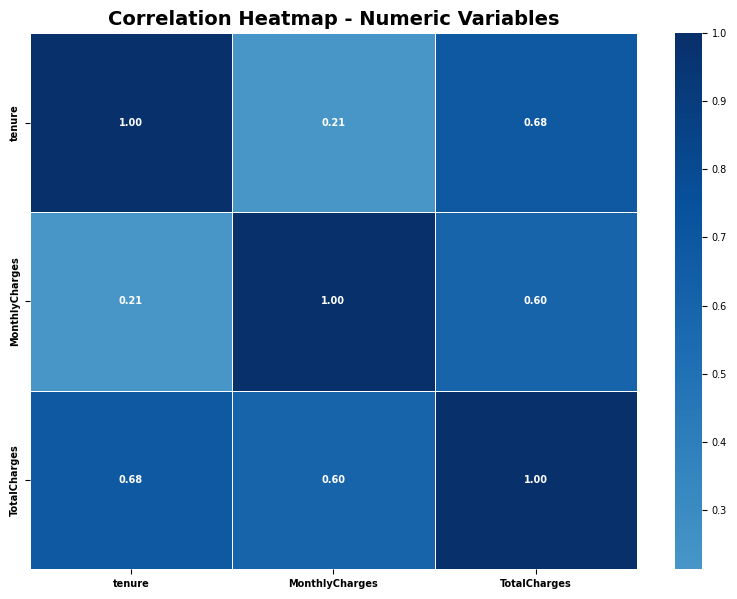

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(),
            annot=True,
            fmt='.2f',
            cmap='Blues',
            center=0,
            linewidths=0.5,
            annot_kws={'fontweight': 'bold'})
plt.title('Correlation Heatmap - Numeric Variables',
          fontsize=14, fontweight='bold')
# Make x and y axis labels bold and empty
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12, fontweight='bold')
# Make x and y tick labels bold
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

**Insights:**
*  tenure and TotalCharges show a moderate positive correlation, indicating long-term customers contribute higher revenue.
*  MonthlyCharges and TotalCharges also display moderate correlation, suggesting higher monthly plans increase overall spending.
*  tenure and MonthlyCharges have weak correlation, indicating monthly pricing is not strongly dependent on customer duration.
*  No extremely high correlations are observed, suggesting severe multicollinearity is unlikely among numerical variables.

### MonthlyCharges by Contract Type and Churn

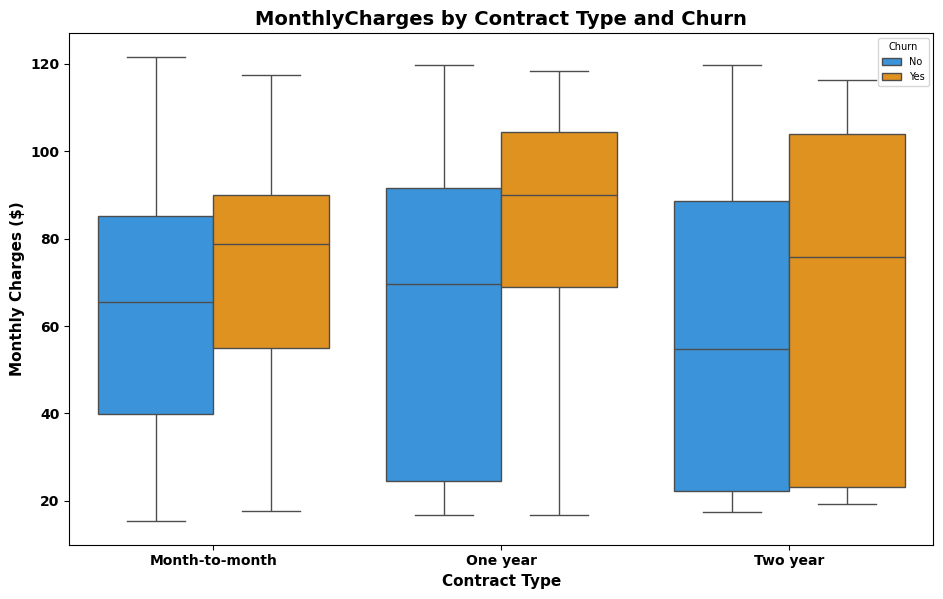

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(
    data=df,
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    palette=['#2196F3', '#FF9800']
)

# Title
plt.title(
    'MonthlyCharges by Contract Type and Churn',
    fontsize=14,
    fontweight='bold'
)

# Legend
plt.legend(
    title='Churn',
    bbox_to_anchor=(1, 1)
)

# Axis labels
plt.xlabel(
    'Contract Type',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Monthly Charges ($)',
    fontsize=11,
    fontweight='bold'
)

# Tick formatting
plt.xticks(
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=10,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Save high-quality figure
plt.savefig(
    'monthlycharges_contract_churn.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

# Show plot
plt.show()

**Insights:**
*  Churned customers generally show higher MonthlyCharges across all contract types.
*  Month-to-month customers exhibit higher churn despite shorter commitment periods.
*  Long-term contract customers show comparatively lower churn behavior.
*  Higher monthly plans appear to be associated with increased churn risk.

### Tenure by Internet Service and Churn

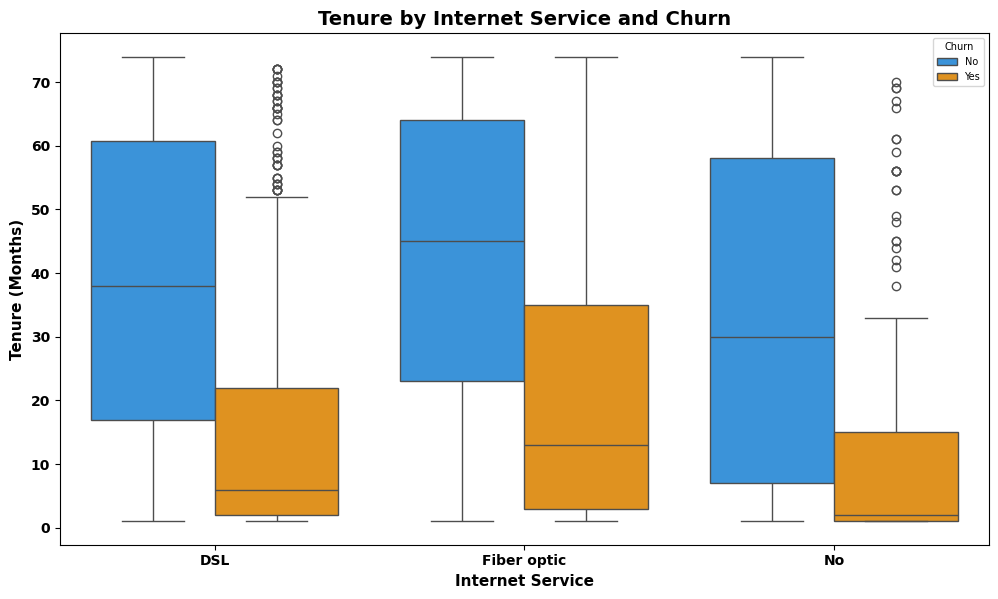

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(
    data=df,
    x='InternetService',
    y='tenure',
    hue='Churn',
    palette=['#2196F3', '#FF9800']
)

# Title
plt.title(
    'Tenure by Internet Service and Churn',
    fontsize=14,
    fontweight='bold'
)

# Axis labels
plt.xlabel(
    'Internet Service',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Tenure (Months)',
    fontsize=11,
    fontweight='bold'
)

# Tick formatting
plt.xticks(
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=10,
    fontweight='bold'
)

# Legend
plt.legend(
    title='Churn',
    bbox_to_anchor=(1, 1)
)

# Tight layout
plt.tight_layout()

# Save high-quality image
plt.savefig(
    'tenure_internetservice_churn.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

# Show plot
plt.show()

**Insights:**
*  Churned customers generally have much lower tenure across all internet service categories.
*  Fiber optic customers show relatively higher churn at lower tenure levels.
*  Customers with longer tenure are more likely to remain retained regardless of internet service type.
*  Early-stage customers appear more vulnerable to churn across all service categories.

### Contract vs Churn vs InternetService

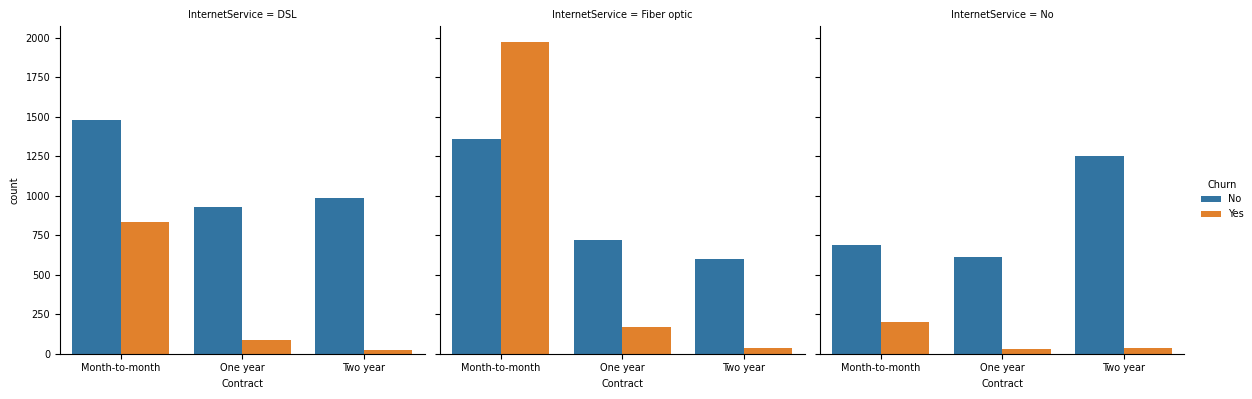

In [ ]:
sns.catplot(
    x='Contract',
    hue='Churn',
    col='InternetService',
    data=df,
    kind='count',
    height=4,
    aspect=1
)
plt.show()

**Insights:**
*  Fiber optic customers on month-to-month contracts show the highest churn levels.
*  Customers with one-year and two-year contracts generally exhibit much lower churn.
*  Long-term contracts appear effective in improving customer retention across all internet service types.
*  Customers without internet service show comparatively low churn overall.

### Tenure vs MonthlyCharges by Churn - Scatterplot

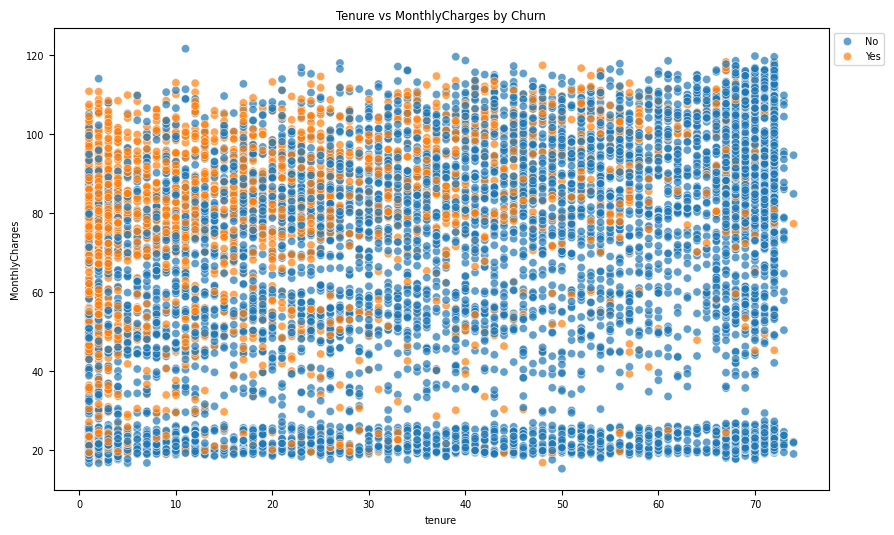

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df,
    alpha=0.7
)
plt.legend(bbox_to_anchor=(1, 1))
plt.title('Tenure vs MonthlyCharges by Churn')
plt.show()

**Insights:**
*  Customers with lower tenure and higher MonthlyCharges are more likely to churn.
*  Long-tenure customers are predominantly associated with non-churn behavior.
*  Higher monthly pricing plans appear to increase churn risk, especially among newer customers.
*  No strong linear relationship is observed between tenure and MonthlyCharges.

### Churn % by Categorical Variables

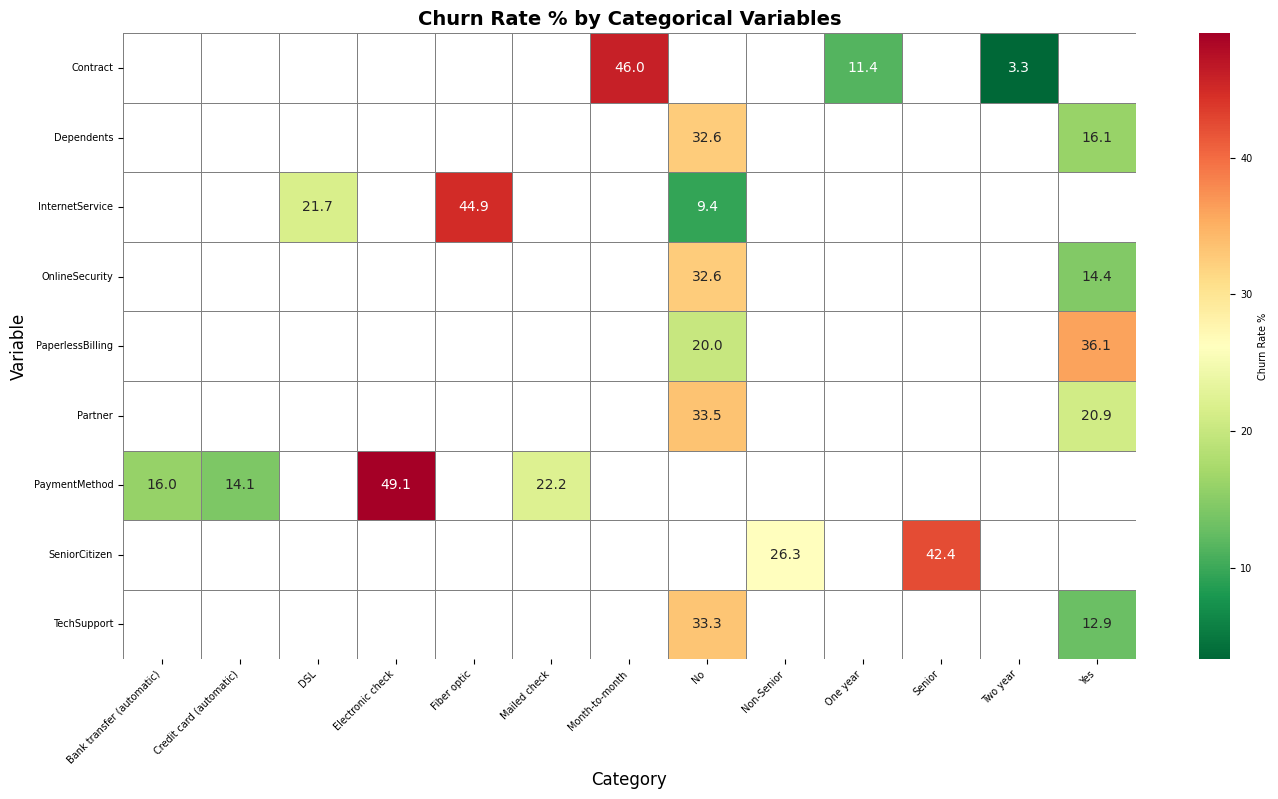


Original df SeniorCitizen values:
SeniorCitizen
0    10608
1     1420
Name: count, dtype: int64


In [ ]:
# Create a temporary copy just for plotting
plot_df = df.copy()
plot_df['SeniorCitizen'] = plot_df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})

# Define categorical columns
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
            'SeniorCitizen', 'Dependents', 'Partner']

# Calculate churn rate for each category
results = []
for col in cat_cols:
    ct = pd.crosstab(plot_df[col], plot_df['Churn'], normalize='index') * 100
    for idx in ct.index:
        results.append({
            'Variable': col,
            'Category': str(idx),
            'Churn Rate': round(ct.loc[idx, 'Yes'], 1)
        })

results_df = pd.DataFrame(results)

# Pivot to create clean heatmap
pivot_df = results_df.pivot(index='Variable',
                            columns='Category',
                            values='Churn Rate')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn_r',
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Churn Rate %'},
            mask=pivot_df.isnull(),
            annot_kws={'size': 10})
plt.title('Churn Rate % by Categorical Variables',
          fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Verify original df is unchanged
print("\nOriginal df SeniorCitizen values:")
print(df['SeniorCitizen'].value_counts())

The heatmap summarizes churn rates across key categorical variables and customer segments. High churn is particularly associated with month-to-month contracts, electronic check payment methods, fiber optic internet service, and senior citizens, while long-term contracts and value-added services such as tech support and online security are linked with lower churn rates.

**Insights:**
*  Month-to-month contracts and electronic check payments show the highest churn rates.
*  Fiber optic customers exhibit higher churn compared to DSL and customers without internet service.
*  Customers without OnlineSecurity or TechSupport are more likely to churn.
*  Senior citizens and customers without dependents show relatively higher churn behavior.
*  Long-term contracts and additional support services strongly contribute to customer retention.

#**Data Preprocessing**


## Train/Validation/Test split

In [ ]:
# Drop gender only
df = df.drop(columns=['gender'])

# Verify
print(df.shape)
print(df.columns.tolist())

(12028, 19)
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Verify shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Verify stratification
print(f"\ny_train distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\ny_val distribution:")
print(y_val.value_counts(normalize=True) * 100)
print(f"\ny_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (8419, 18)
X_val shape:   (1804, 18)
X_test shape:  (1805, 18)

y_train distribution:
Churn
No    71.77812
Yes   28.22188
Name: proportion, dtype: float64

y_val distribution:
Churn
No    71.78492
Yes   28.21508
Name: proportion, dtype: float64

y_test distribution:
Churn
No    71.80055
Yes   28.19945
Name: proportion, dtype: float64


We split the data into train, validation and test sets.

## Missing Value Treatment

In [ ]:
# Check missing values in each split
print("Missing values in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nMissing values in X_val:")
print(X_val.isnull().sum()[X_val.isnull().sum() > 0])

print("\nMissing values in X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Missing values in X_train:
tenure            715
MonthlyCharges    204
TotalCharges      969
dtype: int64

Missing values in X_val:
tenure            159
MonthlyCharges     54
TotalCharges      191
dtype: int64

Missing values in X_test:
tenure            154
MonthlyCharges     43
TotalCharges      201
dtype: int64


In [ ]:
# Check skewness to decide mean vs median imputation
print("Skewness of numeric columns:")
print(X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].skew())

Skewness of numeric columns:
tenure            0.22303
MonthlyCharges   -0.21931
TotalCharges      0.89831
dtype: float64


In [ ]:
# Verify no negatives in any numeric column
# Run BEFORE scaling
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Negative value check before scaling:")
for col in numeric_cols:
    neg_count = (X_train[col] < 0).sum()
    status = "✅" if neg_count == 0 else "❌"
    print(f"{col}: {neg_count} negatives {status}")

Negative value check before scaling:
tenure: 0 negatives ✅
MonthlyCharges: 0 negatives ✅
TotalCharges: 0 negatives ✅


In [ ]:
from sklearn.impute import SimpleImputer

# Mean imputer for tenure and MonthlyCharges
mean_imputer = SimpleImputer(strategy='mean')

# Median imputer for TotalCharges
median_imputer = SimpleImputer(strategy='median')

# Fit ONLY on X_train
mean_imputer.fit(X_train[['tenure', 'MonthlyCharges']])
median_imputer.fit(X_train[['TotalCharges']])

# ← CHECK HERE before transforming
print("Imputer statistics (fitted values):")
print(f"Mean for tenure: {mean_imputer.statistics_[0]:.4f}")
print(f"Mean for MonthlyCharges: {mean_imputer.statistics_[1]:.4f}")
print(f"Median for TotalCharges: {median_imputer.statistics_[0]:.4f}")

# Transform all splits
for X_split in [X_train, X_val, X_test]:
    X_split[['tenure', 'MonthlyCharges']] = mean_imputer.transform(
        X_split[['tenure', 'MonthlyCharges']])
    X_split[['TotalCharges']] = median_imputer.transform(
        X_split[['TotalCharges']])

# Verify minimum
print("\nAfter imputation:")
print(f"TotalCharges min: {X_train['TotalCharges'].min()}")
print(f"tenure min: {X_train['tenure'].min()}")
print(f"Negative TotalCharges: {(X_train['TotalCharges'] < 0).sum()}")

# Verify no missing values remain
print("\nMissing values after imputation:")
for X_split, name in [(X_train, 'X_train'),
                       (X_val, 'X_val'),
                       (X_test, 'X_test')]:
    print(f"\n{name}:")
    print(X_split.isnull().sum()[X_split.isnull().sum() > 0])
    if X_split.isnull().sum().sum() == 0:
        print("No missing values ✅")

Imputer statistics (fitted values):
Mean for tenure: 32.3779
Mean for MonthlyCharges: 64.5773
Median for TotalCharges: 1360.2800

After imputation:
TotalCharges min: 0.06
tenure min: 1.0
Negative TotalCharges: 0

Missing values after imputation:

X_train:
Series([], dtype: int64)
No missing values ✅

X_val:
Series([], dtype: int64)
No missing values ✅

X_test:
Series([], dtype: int64)
No missing values ✅


Used SimpleImputer to handle the missing values. Imputed the columns `tenure` and `MonthlyCharges`with nmean and imputed the column `TotalCharges` with median.

## Outlier check

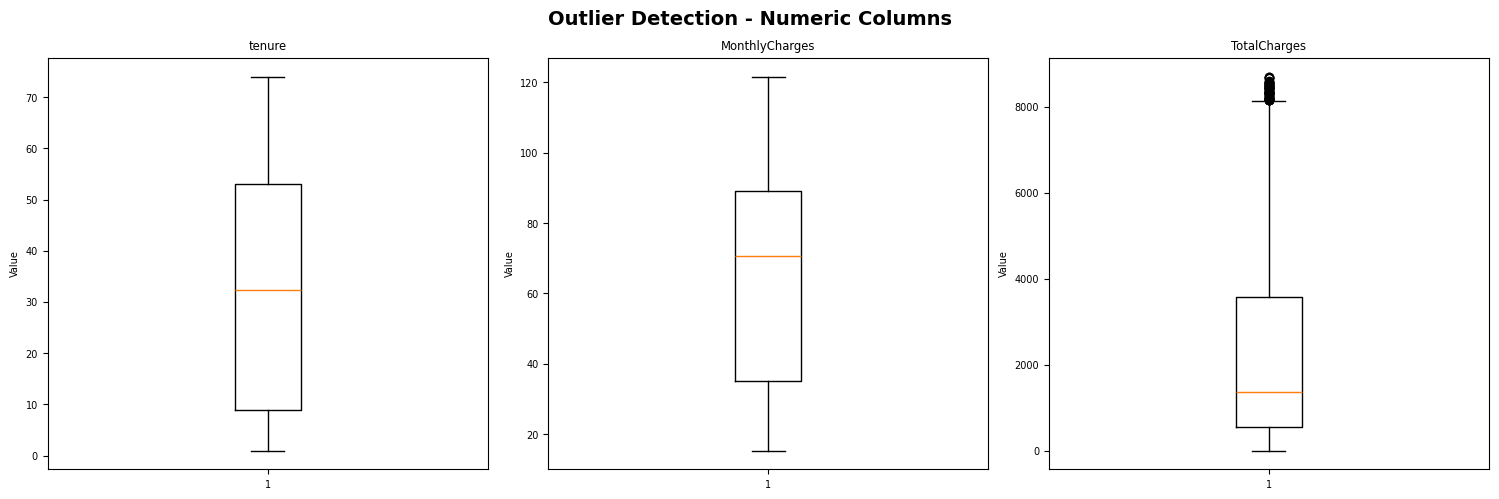

Outlier count using IQR method:

tenure:
  Lower bound: -57.00
  Upper bound: 119.00
  Outlier count: 0
  Outlier %: 0.00%

MonthlyCharges:
  Lower bound: -46.24
  Upper bound: 170.40
  Outlier count: 0
  Outlier %: 0.00%

TotalCharges:
  Lower bound: -4020.30
  Upper bound: 8143.48
  Outlier count: 51
  Outlier %: 0.61%


In [ ]:
# Boxplot to visualise outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    axes[i].boxplot(X_train[col].dropna())
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection - Numeric Columns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR method to quantify outliers
print("Outlier count using IQR method:")
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)]
    print(f"\n{col}:")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outlier count: {len(outliers)}")
    print(f"  Outlier %: {len(outliers)/len(X_train)*100:.2f}%")

In [ ]:
# Check the outlier values in TotalCharges
Q1 = X_train['TotalCharges'].quantile(0.25)
Q3 = X_train['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = X_train[X_train['TotalCharges'] > upper]['TotalCharges']
print("TotalCharges outlier values:")
print(outliers.describe())
print(f"\nMax TotalCharges in dataset: {X_train['TotalCharges'].max():.2f}")
print(f"Upper bound: {upper:.2f}")

TotalCharges outlier values:
count     51.00000
mean    8379.25000
std      159.33800
min     8152.30000
25%     8229.49500
50%     8349.70000
75%     8490.43500
max     8701.85000
Name: TotalCharges, dtype: float64

Max TotalCharges in dataset: 8701.85
Upper bound: 8143.48


Since the detected outliers represented genuine high-value customers rather than data  entry errors, no outlier treatment was applied to avoid losing important business information.

## Feature Engineering

### Feature Transformation

In [ ]:
# Apply a square root transformation instead
sqrt_skew = np.sqrt(X_train['TotalCharges']).skew()
print(f"Square Root Skewness: {sqrt_skew:.2f}")


Square Root Skewness: 0.37


A square root transformation was applied to reduce the skewness of the TotalCharges variable. After transformation, the skewness reduced to 0.37, indicating a more balanced distribution suitable for modeling.


In [ ]:
X_train['TotalCharges'] = np.sqrt(X_train['TotalCharges'])
X_val['TotalCharges'] = np.sqrt(X_val['TotalCharges'])
X_test['TotalCharges'] = np.sqrt(X_test['TotalCharges'])


### One Hot Encoding

In [ ]:
# Check categorical columns
print("Categorical columns:")
print(X_train.select_dtypes(include='object').columns.tolist())

print("\nNumeric columns:")
print(X_train.select_dtypes(include='number').columns.tolist())

Categorical columns:
['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Define all categorical columns
cat_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'PaperlessBilling', 'InternetService', 'Contract',
            'PaymentMethod']

# Step 1: Fit OHE on X_train ONLY
ohe = OneHotEncoder(sparse_output=False,
                    handle_unknown='ignore',
                    drop='if_binary')  # drops one column for binary features
ohe.fit(X_train[cat_cols])

# Step 2: Apply transformation function
def apply_ohe(X, ohe, cat_cols):
    # Transform categorical columns
    ohe_array = ohe.transform(X[cat_cols])
    # Create dataframe with encoded columns
    ohe_df = pd.DataFrame(ohe_array,
                          columns=ohe.get_feature_names_out(cat_cols),
                          index=X.index)
    # Drop original categorical columns
    X = X.drop(columns=cat_cols)
    # Concatenate encoded columns
    X = pd.concat([X, ohe_df], axis=1)
    return X

# Step 3: Transform all three splits
X_train = apply_ohe(X_train, ohe, cat_cols)
X_val = apply_ohe(X_val, ohe, cat_cols)
X_test = apply_ohe(X_test, ohe, cat_cols)

# Step 4: Encode target variable
y_train = y_train.replace({'No': 0, 'Yes': 1})
y_val = y_val.replace({'No': 0, 'Yes': 1})
y_test = y_test.replace({'No': 0, 'Yes': 1})

# Step 5: Verify
print("Shapes after encoding:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nColumns after encoding:")
print(X_train.columns.tolist())

print("\nTarget distribution after encoding:")
print(f"y_train:\n{y_train.value_counts()}")
print(f"\ny_val:\n{y_val.value_counts()}")
print(f"\ny_test:\n{y_test.value_counts()}")

Shapes after encoding:
X_train: (8419, 25)
X_val:   (1804, 25)
X_test:  (1805, 25)

Columns after encoding:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Target distribution after encoding:
y_train:
Churn
0    6043
1    2376
Name: count, dtype: int64

y_val:
Churn
0    1295
1     509
Name: count, dtype: int64

y_test:
Churn
0    1296
1     509
Name: count, dtype: int64


In [ ]:
# Check unique categories
print(X_train[['InternetService_DSL',
               'InternetService_Fiber optic',
               'InternetService_No']].sum())

InternetService_DSL           3074.00000
InternetService_Fiber optic   3398.00000
InternetService_No            1947.00000
dtype: float64


In [ ]:
# Drop one category from each multi-class column
cols_to_drop = ['InternetService_No',    # DSL and Fiber optic remaining
                'Contract_Two year',      # Month-to-month and One year remaining
                'PaymentMethod_Mailed check']  # 3 payment methods remaining

X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Verify
print("Shapes after dropping reference categories:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nFinal columns:")
print(X_train.columns.tolist())

Shapes after dropping reference categories:
X_train: (8419, 22)
X_val:   (1804, 22)
X_test:  (1805, 22)

Final columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'Contract_Month-to-month', 'Contract_One year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']


## Feature Scaling

In [ ]:
# Only scale continuous numeric columns
# SeniorCitizen is binary (0/1) — does not need scaling
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Before scaling:")
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(X_train[scale_cols].describe())



Before scaling:
       tenure  MonthlyCharges  TotalCharges
count 8419.00         8419.00       8419.00
mean    32.38           64.58         40.92
std     23.71           29.96         23.24
min      1.00           15.29          0.24
25%      9.00           35.00         23.26
50%     32.38           70.50         36.88
75%     53.00           89.16         59.85
max     74.00          121.67         93.28


In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Refit scaler on corrected X_train
scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

# Transform all splits
X_train[scale_cols] = scaler.transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Verify
print("After scaling:")
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(X_train[scale_cols].describe())

After scaling:
       tenure  MonthlyCharges  TotalCharges
count 8419.00         8419.00       8419.00
mean    -0.00           -0.00          0.00
std      1.00            1.00          1.00
min     -1.32           -1.65         -1.75
25%     -0.99           -0.99         -0.76
50%     -0.00            0.20         -0.17
75%      0.87            0.82          0.81
max      1.76            1.91          2.25


Numerical variables were standardized using StandardScaler to ensure all features contributed proportionally during model training.

# **Model building - Baseline Model**

## Model evaluation criterion


The model can make incorrect predictions in two ways:

*  Predicting that a customer will not churn, but in reality, the customer does churn (False Negative). This can lead to customer loss, reduced revenue, and missed retention opportunities.

*  Predicting that a customer will churn, but in reality, the customer does not churn (False Positive). This may result in unnecessary retention offers or additional marketing costs.

Which case is more important?

Missing a potential churn customer (False Negative) is more costly to the business than incorrectly identifying a loyal customer as a churn risk.
How can this loss be reduced?

To minimize customer loss, the model should focus on reducing False Negatives. Therefore, Recall was selected as the primary evaluation metric, as higher Recall improves the model’s ability to correctly identify customers who are likely to churn.

Additional Evaluation Metrics
Secondary evaluation metrics used include:

**Accuracy:** Measures the overall correctness of the model.</br>
**Precision:** Measures how many predicted churn customers actually churned. </br>
**Recall:** Measures the model’s ability to correctly identify actual churn customers. </br>
**F1-Score:** Provides a balance between Precision and Recall. </br>
**Confusion Matrix:** Helps visualize correct and incorrect predictions across churn classes. </br>
ROC-AUC Score: Evaluates the model’s ability to distinguish between churn and non-churn customers across different classification thresholds.

## Logistic Regression - Baseline Model

In [ ]:
import statsmodels.api as sm

# Add constant for intercept
X_train_sm = sm.add_constant(X_train)
X_val_sm = sm.add_constant(X_val)

# Fit logistic regression
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.422585
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 8419
Model:                          Logit   Df Residuals:                     8396
Method:                           MLE   Df Model:                           22
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.2898
Time:                        18:48:16   Log-Likelihood:                -3557.7
converged:                       True   LL-Null:                       -5009.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.9335

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Predictions ───────────────────────────────────────────────────────
X_test_sm    = sm.add_constant(X_test)
X_train_sm   = sm.add_constant(X_train)

y_train_prob1= result.predict(X_train_sm)
y_val_prob1  = result.predict(X_val_sm)
y_test_prob1 = result.predict(X_test_sm)

y_train_pred1= (y_train_prob1  >= 0.5).astype(int)
y_val_pred1  = (y_val_prob1  >= 0.5).astype(int)
y_test_pred1 = (y_test_prob1 >= 0.5).astype(int)

# ── Metrics Table ─────────────────────────────────────────────────────
for split, y_true, y_pred, y_prob in [
    ('Train', y_train,  y_train_pred1,  y_train_prob1),
    ('Validation', y_val,  y_val_pred1,  y_val_prob1)
]:
    print(f"\n{'=' * 50}")
    print(f"BASELINE MODEL — {split.upper()} SET")
    print(f"{'=' * 50}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred)   * 100:.2f}%")
    print(f"Precision: {precision_score(y_true, y_pred)  * 100:.2f}%")
    print(f"Recall   : {recall_score(y_true, y_pred)     * 100:.2f}%")
    print(f"F1 Score : {f1_score(y_true, y_pred)         * 100:.2f}%")
    print(f"AUC-ROC  : {roc_auc_score(y_true, y_prob)    * 100:.2f}%")


BASELINE MODEL — TRAIN SET
Accuracy : 80.32%
Precision: 67.63%
Recall   : 58.04%
F1 Score : 62.47%
AUC-ROC  : 84.95%

BASELINE MODEL — VALIDATION SET
Accuracy : 80.54%
Precision: 69.17%
Recall   : 55.99%
F1 Score : 61.89%
AUC-ROC  : 85.34%


*  The baseline Logistic Regression model shows stable performance across both training and validation datasets, indicating good generalization with minimal overfitting.
*  The model achieved good Accuracy (80%) and strong ROC-AUC (~85%), indicating good class separation capability.
*  Precision is higher than Recall, which means the model is conservative in predicting churn and produces fewer false positives.
*  However, the comparatively lower Recall suggests that some churn customers are still being missed by the model.

In [ ]:
from sklearn.metrics import classification_report

# ── Classification Report ─────────────────────────────────────────────
for split, y_true, y_pred in [
    ('Train',       y_train, y_train_pred1),
    ('Validation', y_val,  y_val_pred1)
]:
    print(f"\n{'=' * 50}")
    print(f"CLASSIFICATION REPORT — {split.upper()} SET")
    print(f"{'=' * 50}")
    print(classification_report(y_true, y_pred,
                                target_names=['No Churn', 'Churned'],
                                digits=2))


CLASSIFICATION REPORT — TRAIN SET
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      6043
     Churned       0.68      0.58      0.62      2376

    accuracy                           0.80      8419
   macro avg       0.76      0.74      0.75      8419
weighted avg       0.80      0.80      0.80      8419


CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1295
     Churned       0.69      0.56      0.62       509

    accuracy                           0.81      1804
   macro avg       0.77      0.73      0.74      1804
weighted avg       0.80      0.81      0.80      1804



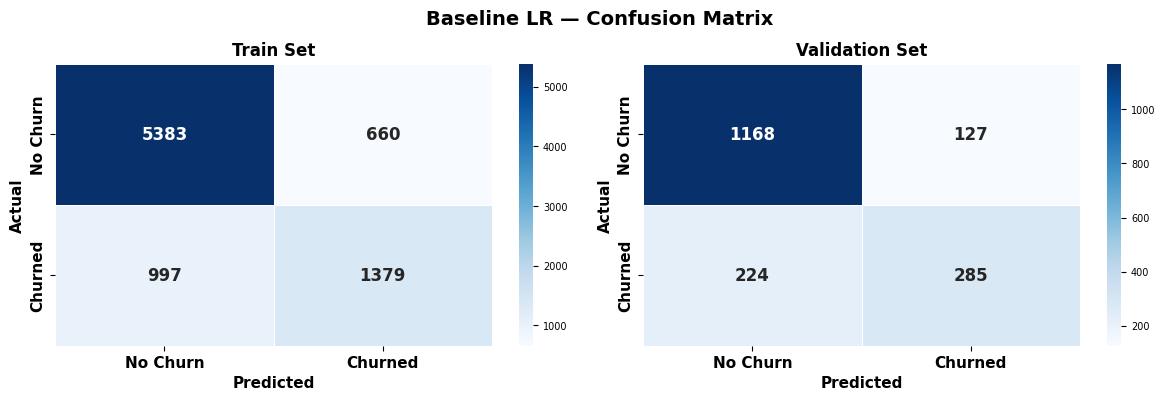

In [ ]:
# ── Confusion Matrix — Validation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Baseline LR — Confusion Matrix',
             fontsize=14, fontweight='bold')

for ax, (split, y_true, y_pred) in zip(axes, [
     ('Train',       y_train, y_train_pred1),
    ('Validation', y_val,  y_val_pred1)
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'],
                linewidths=0.5,
                annot_kws={'size': 12, 'weight': 'bold'},
                ax=ax)
    ax.set_title(f'{split} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(11)

plt.tight_layout()
plt.savefig('cm_baseline_lr.png', dpi=150, bbox_inches='tight')
plt.show()

*  The confusion matrix shows that the model correctly identifies a large number of non-churn customers in both training and validation datasets.
*  The model also captures a reasonable number of churn customers; however, some churn cases are still misclassified as non-churn, contributing to lower Recall.
*  The train and validation confusion matrices follow a similar pattern, indicating that the baseline Logistic Regression model generalizes well without severe overfitting.
*  False negatives are comparatively higher than false positives, suggesting that the model is more conservative while predicting churn customers.

## Smote model

In [ ]:
from imblearn.over_sampling import SMOTE

# ── Before SMOTE ─────────────────────────────────────────────────────
print(f"Before Oversampling, counts of label 'No Churn' : {sum(y_train == 0)}")
print(f"Before Oversampling, counts of label 'Churned'  : {sum(y_train == 1)}")

# ── Apply SMOTE ───────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ── After SMOTE ───────────────────────────────────────────────────────
print(f"\nAfter Oversampling, counts of label 'No Churn' : {sum(y_train_smote == 0)}")
print(f"After Oversampling, counts of label 'Churned'  : {sum(y_train_smote == 1)}")

print(f"\nAfter Oversampling, the shape of X_train: {X_train_smote.shape}")
print(f"After Oversampling, the shape of y_train: {y_train_smote.shape}")

Before Oversampling, counts of label 'No Churn' : 6043
Before Oversampling, counts of label 'Churned'  : 2376

After Oversampling, counts of label 'No Churn' : 6043
After Oversampling, counts of label 'Churned'  : 6043

After Oversampling, the shape of X_train: (12086, 22)
After Oversampling, the shape of y_train: (12086,)


In [ ]:
import statsmodels.api as sm

# ── Add constant ──────────────────────────────────────────────────────
X_train_smote_sm = sm.add_constant(X_train_smote)
X_val_sm         = sm.add_constant(X_val)
X_test_sm        = sm.add_constant(X_test)

# ── Train ─────────────────────────────────────────────────────────────
logit_smote  = sm.Logit(y_train_smote, X_train_smote_sm)
result_smote = logit_smote.fit()
print(result_smote.summary())

Optimization terminated successfully.
         Current function value: 0.466667
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                12086
Model:                          Logit   Df Residuals:                    12063
Method:                           MLE   Df Model:                           22
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.3267
Time:                        18:48:37   Log-Likelihood:                -5640.1
converged:                       True   LL-Null:                       -8377.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.1183

In [ ]:
# ── Predictions ───────────────────────────────────────────────────────
y_train_prob_smote = result_smote.predict(X_train_smote_sm)
y_val_prob_smote  = result_smote.predict(X_val_sm)
y_test_prob_smote = result_smote.predict(X_test_sm)

y_train_pred_smote = (y_train_prob_smote  >= 0.5).astype(int)
y_val_pred_smote  = (y_val_prob_smote  >= 0.5).astype(int)
y_test_pred_smote = (y_test_prob_smote >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

for split, y_true, y_pred, y_prob in [
    ('Train', y_train_smote,  y_train_pred_smote,  y_train_prob_smote),
    ('Validation', y_val,  y_val_pred_smote,  y_val_prob_smote)
]:
    print(f"\n{'=' * 50}")
    print(f"SMOTE MODEL — {split.upper()} SET")
    print(f"{'=' * 50}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred)  * 100:.2f}%")
    print(f"Precision: {precision_score(y_true, y_pred) * 100:.2f}%")
    print(f"Recall   : {recall_score(y_true, y_pred)    * 100:.2f}%")
    print(f"F1 Score : {f1_score(y_true, y_pred)        * 100:.2f}%")
    print(f"AUC-ROC  : {roc_auc_score(y_true, y_prob)   * 100:.2f}%")


SMOTE MODEL — TRAIN SET
Accuracy : 78.20%
Precision: 76.22%
Recall   : 81.98%
F1 Score : 78.99%
AUC-ROC  : 86.02%

SMOTE MODEL — VALIDATION SET
Accuracy : 77.55%
Precision: 57.45%
Recall   : 78.78%
F1 Score : 66.45%
AUC-ROC  : 85.03%


*  After applying SMOTE, the model’s Recall improved significantly from the baseline model, indicating better identification of churn customers.
*  F1-score also improved considerably, showing a better balance between Precision and Recall.
*  Although Accuracy decreased slightly, the improvement in Recall is beneficial for churn prediction, where identifying potential churn customers is more important.
*  The train and validation metrics are reasonably close, suggesting that the SMOTE Logistic Regression model generalizes well without severe overfitting.

In [ ]:
from sklearn.metrics import classification_report

for split, y_true, y_pred in [
    ('Train', y_train_smote,  y_train_pred_smote),
    ('Validation', y_val,  y_val_pred_smote)
]:
    print(f"\n{'=' * 50}")
    print(f"CLASSIFICATION REPORT — {split.upper()} SET")
    print(f"{'=' * 50}")
    print(classification_report(y_true, y_pred,
                                target_names=['No Churn', 'Churned'],
                                digits=2))


CLASSIFICATION REPORT — TRAIN SET
              precision    recall  f1-score   support

    No Churn       0.81      0.74      0.77      6043
     Churned       0.76      0.82      0.79      6043

    accuracy                           0.78     12086
   macro avg       0.78      0.78      0.78     12086
weighted avg       0.78      0.78      0.78     12086


CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1295
     Churned       0.57      0.79      0.66       509

    accuracy                           0.78      1804
   macro avg       0.74      0.78      0.75      1804
weighted avg       0.81      0.78      0.78      1804



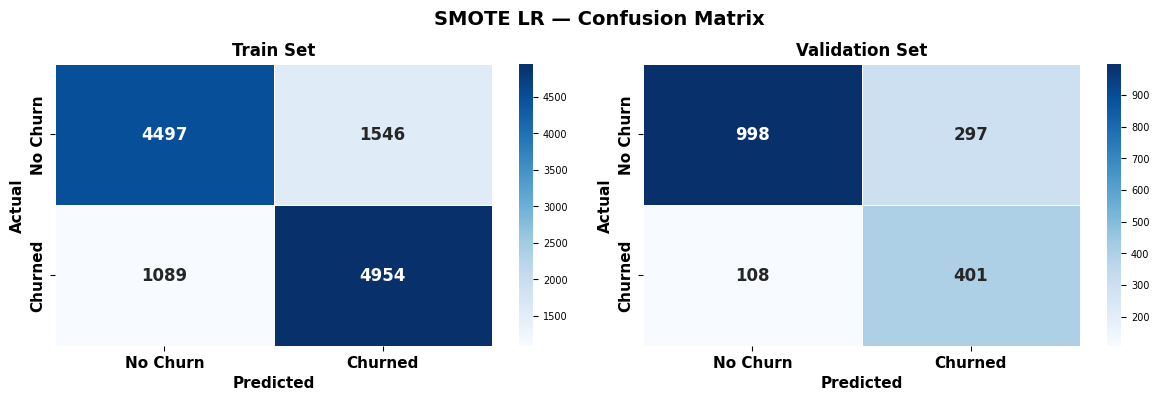

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SMOTE LR — Confusion Matrix',
             fontsize=14, fontweight='bold')

for ax, (split, y_true, y_pred) in zip(axes, [
    ('Train',      y_train_smote, y_train_pred_smote),
    ('Validation', y_val,  y_val_pred_smote),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=['No Churn', 'Churned'],
                yticklabels=['No Churn', 'Churned'],
                linewidths=0.5,
                annot_kws={'size': 12, 'weight': 'bold'},
                ax=ax)
    ax.set_title(f'{split} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(11)

plt.tight_layout()
plt.savefig('cm_smote_lr.png', dpi=150, bbox_inches='tight')
plt.show()

*  The confusion matrix shows that after applying SMOTE, the model identifies a significantly higher number of churn customers correctly, leading to improved Recall.
*  False negatives reduced considerably compared to the baseline model, indicating better churn detection capability.
*  However, false positives increased, meaning some non-churn customers were incorrectly predicted as churn, which slightly reduced Precision and Accuracy.
*  The train and validation confusion matrices show similar prediction patterns, suggesting that the SMOTE Logistic Regression model generalizes reasonably well without severe overfitting.



## Model Comparison

In [ ]:
from sklearn.metrics import roc_curve

# ── Comparison Table — Both Train and Val ─────────────────────────────
results = []

for model_name, data_by_split in {
    'Baseline LR' : {
        'Train':      (y_train,      y_train_pred1,      y_train_prob1),
        'Validation': (y_val,        y_val_pred1,        y_val_prob1)
    },
    'SMOTE LR'    : {
        'Train':      (y_train_smote, y_train_pred_smote, y_train_prob_smote),
        'Validation': (y_val,         y_val_pred_smote,   y_val_prob_smote)
    }
}.items():
    for split, (y_true, y_pred, y_prob) in data_by_split.items():
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        results.append({
            'Model'          : model_name,
            'Split'          : split,
            'Accuracy'       : round(accuracy_score(y_true, y_pred)  * 100, 2),
            'Precision'      : round(precision_score(y_true, y_pred) * 100, 2),
            'Recall'         : round(recall_score(y_true, y_pred)    * 100, 2),
            'F1 Score'       : round(f1_score(y_true, y_pred)        * 100, 2),
            'AUC-ROC'        : round(roc_auc_score(y_true, y_prob)   * 100, 2),
            'True Positive'  : tp,
            'False Positive' : fp,
            'True Negative'  : tn,
            'False Negative' : fn,
        })

results_df = pd.DataFrame(results)

# Set display option for float format
pd.set_option('display.float_format', '{:.2f}'.format)

print("=" * 75)
print("MODEL COMPARISON — TRAIN SET")
print("=" * 75)
print(results_df[results_df['Split'] == 'Train'].to_string(index=False))

print("\n" + "=" * 75)
print("MODEL COMPARISON — VALIDATION SET")
print("=" * 75)
print(results_df[results_df['Split'] == 'Validation'].to_string(index=False))

# Reset display option to default
pd.reset_option('display.float_format')

MODEL COMPARISON — TRAIN SET
      Model Split  Accuracy  Precision  Recall  F1 Score  AUC-ROC  True Positive  False Positive  True Negative  False Negative
Baseline LR Train     80.32      67.63   58.04     62.47    84.95           1379             660           5383             997
   SMOTE LR Train     78.20      76.22   81.98     78.99    86.02           4954            1546           4497            1089

MODEL COMPARISON — VALIDATION SET
      Model      Split  Accuracy  Precision  Recall  F1 Score  AUC-ROC  True Positive  False Positive  True Negative  False Negative
Baseline LR Validation     80.54      69.17   55.99     61.89    85.34            285             127           1168             224
   SMOTE LR Validation     77.55      57.45   78.78     66.45    85.03            401             297            998             108


*  The baseline Logistic Regression model achieved higher Accuracy and Precision, indicating fewer false positive churn predictions and better overall correctness.
*  However, the baseline model showed lower Recall and higher False Negatives, meaning many actual churn customers were missed.
*  After applying SMOTE, the model’s Recall improved significantly from 58.04% to 81.98% (Train) and from 55.99% to 78.78% (Validation), showing much better churn detection capability.
*  The number of False Negatives reduced considerably in the SMOTE model, which is beneficial for churn prediction where identifying potential churn customers is important.
*  Although SMOTE improved Recall and F1-score, False Positives increased, leading to a reduction in Precision and Accuracy.
*  Both models maintained similar ROC-AUC values (~85%), indicating good class separation capability.
*  The train and validation metrics for both models are reasonably consistent, suggesting acceptable generalization without severe overfitting.

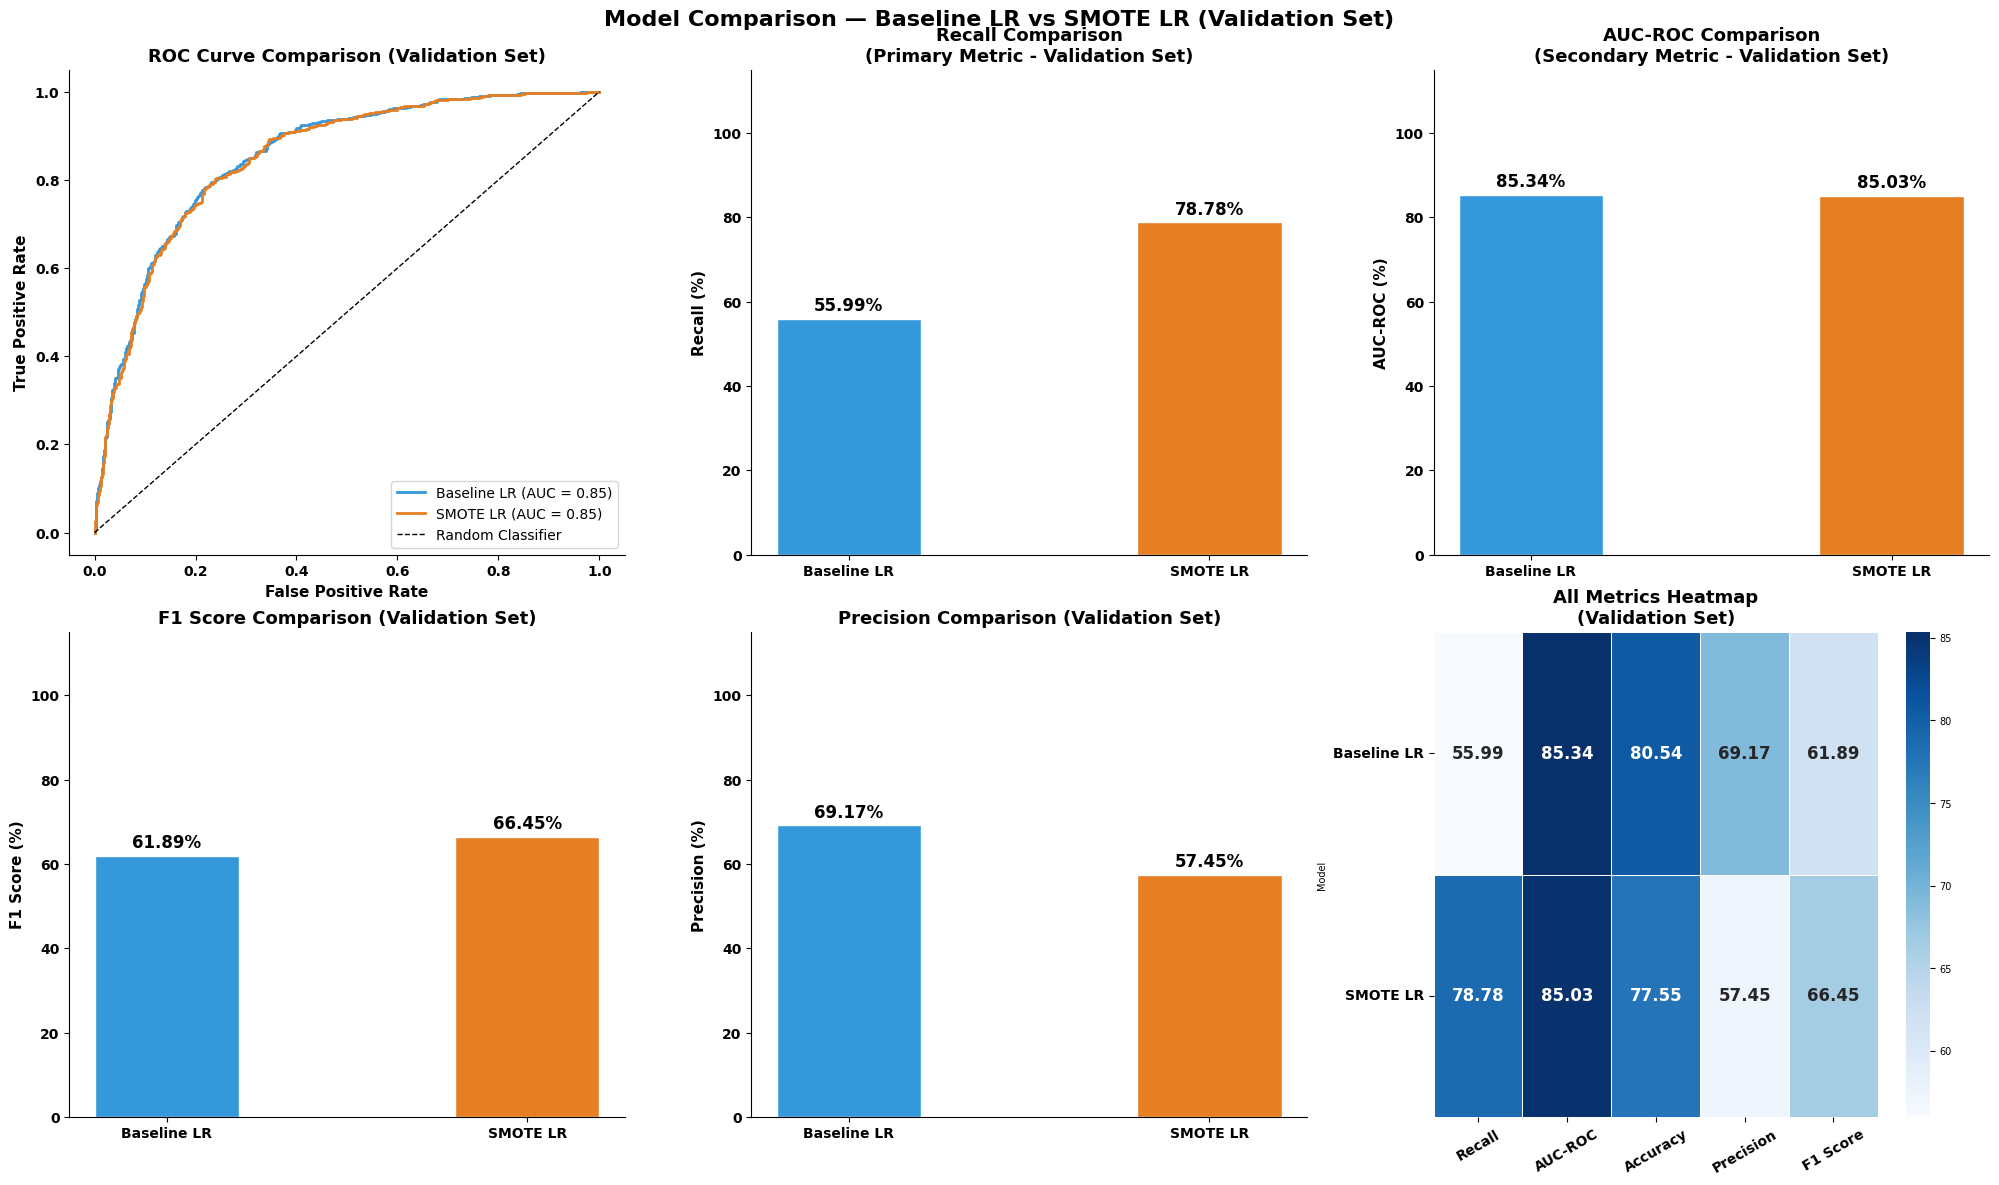

In [ ]:
# ── Comparison Plots ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Comparison — Baseline LR vs SMOTE LR (Validation Set)',
             fontsize=16, fontweight='bold')

colors      = ['#3498db', '#e67e22']
validation_df = results_df[results_df['Split'] == 'Validation'].reset_index(drop=True)
models_dict = {
    'Baseline LR' : (y_val_pred1,       y_val_prob1),
    'SMOTE LR'    : (y_val_pred_smote,  y_val_prob_smote)
}

# ── 1. ROC Curve ─────────────────────────
ax = axes[0, 0]
for (model_name, (y_pred, y_prob)), color in zip(models_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc         = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{model_name} (AUC = {auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curve Comparison (Validation Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)

# ── 2. Recall ─────────────────────────
ax = axes[0, 1]
bars = ax.bar(validation_df['Model'], validation_df['Recall'],
              color=colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.2f%%', fontsize=12,
             padding=3, fontweight='bold')
ax.set_title('Recall Comparison\n(Primary Metric - Validation Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Recall (%)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)

# ── 3. AUC-ROC ─────────────────────────
ax = axes[0, 2]
bars = ax.bar(validation_df['Model'], validation_df['AUC-ROC'],
              color=colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.2f%%', fontsize=12,
             padding=3, fontweight='bold')
ax.set_title('AUC-ROC Comparison\n(Secondary Metric - Validation Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AUC-ROC (%)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)

# ── 4. F1 Score ─────────────────────────
ax = axes[1, 0]
bars = ax.bar(validation_df['Model'], validation_df['F1 Score'],
              color=colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.2f%%', fontsize=12,
             padding=3, fontweight='bold')
ax.set_title('F1 Score Comparison (Validation Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score (%)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)

# ── 5. Precision ─────────────────────────
ax = axes[1, 1]
bars = ax.bar(validation_df['Model'], validation_df['Precision'],
              color=colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.2f%%', fontsize=12,
             padding=3, fontweight='bold')
ax.set_title('Precision Comparison (Validation Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(10)

# ── 6. Metrics Heatmap ─ fixed overlapping ─────────────
ax = axes[1, 2]
heatmap_data = validation_df.set_index('Model')[
    ['Recall', 'AUC-ROC', 'Accuracy', 'Precision', 'F1 Score']
]
sns.heatmap(heatmap_data, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'},
            ax=ax)
ax.set_title('All Metrics Heatmap\n(Validation Set)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')                                          # ✅ remove overlapping x label
ax.tick_params(axis='x', labelsize=10, rotation=30)       # ✅ rotate x labels
ax.tick_params(axis='y', labelsize=10, rotation=0)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

*  SMOTE LR is selected as the better model based on the primary metric Recall.

*  Although the baseline Logistic Regression model achieved higher Precision and Accuracy, the SMOTE Logistic Regression model significantly improved Recall and F1-score while maintaining similar ROC-AUC performance. Since minimizing missed churn customers was the primary business objective, the SMOTE Logistic Regression model was preferred.

# **Model Building - Advanced Models**

After establishing the baseline Logistic Regression model, additional machine learning algorithms were explored to improve churn prediction performance. Multiple advanced classification models were developed to evaluate whether ensemble-based and boosting techniques could better capture complex customer churn patterns and improve identification of potential churners.

          *  Decision Tree
          *  Random Forest
          *  AdaBoost
          *  Gradient Boosting
          *  XGBoost

Along with advanced model building, statistical model improvement techniques including multicollinearity analysis using VIF and removal of statistically insignificant variables based on p-values were also performed on the Logistic Regression model to enhance model interpretability and performance. These approaches were evaluated to identify models that could better capture complex customer churn patterns and improve churn detection capability.

## Logistic Regression - Model Performance Improvement

*  "A baseline Logistic Regression model was built using all 22 features to establish a performance benchmark. Model performance improvement techniques including multicollinearity check (VIF) and p-value based feature selection were applied to the baseline model to identify and remove insignificant and redundant features before proceeding to advanced model building."

*  "The baseline Logistic Regression model established in the interim report achieved a Recall of 55.99% and AUC-ROC of 85.34% on the validation set. To improve upon this, the following feature selection steps were applied."


### Detecting and Dealing with Multicollinearity

There are different ways of detecting (or testing for) multicollinearity. One such way is using the Variation Inflation Factor (VIF).

* **Variance  Inflation  factor**:  Variance  inflation  factors  measure  the  inflation  in  the variances of the regression coefficients estimates due to collinearities that exist among the  predictors.  It  is  a  measure  of  how  much  the  variance  of  the  estimated  regression coefficient $\beta_k$ is "inflated" by  the  existence  of  correlation  among  the  predictor variables in the model.

* **General Rule of thumb**:
  - If VIF is 1 then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence  the variance of $\beta_k$ is not inflated at all
  - If VIF exceeds 5, we say there is moderate multicollinearity
  - If VIF is equal or exceeding 10, it shows signs of high multi-collinearity

In [ ]:
# CHECK MULTICOLLINEARITY USING VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Add constant
X_train_vif = sm.add_constant(X_train)

# Create VIF dataframe
vif_df = pd.DataFrame()

vif_df['Feature'] = X_train_vif.columns

vif_df['VIF'] = [
    variance_inflation_factor(X_train_vif.values, i)
    for i in range(X_train_vif.shape[1])
]

# Sort VIF values
vif_df = vif_df.sort_values(by='VIF', ascending=False)

# Display VIF table
print(vif_df)

                                    Feature        VIF
0                                     const  52.199437
17              InternetService_Fiber optic   9.119989
3                            MonthlyCharges   7.357588
16                      InternetService_DSL   5.442955
18                  Contract_Month-to-month   3.017380
4                              TotalCharges   2.921579
2                                    tenure   2.412139
22           PaymentMethod_Electronic check   2.236698
21    PaymentMethod_Credit card (automatic)   1.834304
20  PaymentMethod_Bank transfer (automatic)   1.769566
13                          StreamingTV_Yes   1.757897
14                      StreamingMovies_Yes   1.740816
19                        Contract_One year   1.637107
7                          PhoneService_Yes   1.557130
11                     DeviceProtection_Yes   1.539288
12                          TechSupport_Yes   1.508201
8                         MultipleLines_Yes   1.451281
9         

Multicollinearity was checked using Variance Inflation Factor (VIF). Most features had VIF values below 5, indicating low multicollinearity. Although InternetService_Fiber optic and MonthlyCharges showed moderately higher VIF values, they were within an acceptable range and retained due to their business importance.

### Removing high p-value variables

In [ ]:
import statsmodels.api as sm
# Add constant
X_train_sm = sm.add_constant(X_train)

# Build Logistic Regression model
logit_model = sm.Logit(y_train, X_train_sm)

# Fit model
result = logit_model.fit()

# Display summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.422585
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 8419
Model:                          Logit   Df Residuals:                     8396
Method:                           MLE   Df Model:                           22
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.2898
Time:                        18:50:38   Log-Likelihood:                -3557.7
converged:                       True   LL-Null:                       -5009.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.9335

In [ ]:
# Manually specify only the 3 features to remove
# Keeping PaymentMethod_Credit card (automatic) due to dummy variable group logic

features_to_remove = [
    'Partner_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

X_train_reduced = X_train.drop(columns=features_to_remove)
X_val_reduced   = X_val.drop(columns=features_to_remove)
X_test_reduced  = X_test.drop(columns=features_to_remove)

print(f"Remaining features: {X_train_reduced.shape[1]}")
print("\nRemoved features:")
print(features_to_remove)
print("\nRetained despite borderline p-value:")
print("PaymentMethod_Credit card (automatic) - retained due to dummy variable group")

Remaining features: 19

Removed features:
['Partner_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']

Retained despite borderline p-value:
PaymentMethod_Credit card (automatic) - retained due to dummy variable group


All variables with p-value > 0.05 were removed, except `PaymentMethod_Credit card (automatic)` (p=0.052), which was retained as it belongs to the PaymentMethod dummy variable group. Removing individual dummy categories distorts reference category interpretation. The three removed features — `Partner_Yes`, `StreamingTV_Yes`, and `StreamingMovies_Yes` — showed clearly insignificant p-values with no meaningful business distinction.


### Improved LR

In [ ]:
import statsmodels.api as sm

# ============================================================
# BUILD REDUCED LOGISTIC REGRESSION MODEL
# ============================================================

# Add constant
X_train_reduced_sm = sm.add_constant(X_train_reduced)
X_val_reduced_sm   = sm.add_constant(X_val_reduced)
X_test_reduced_sm  = sm.add_constant(X_test_reduced)

# Build Logistic Regression model
logit_reduced = sm.Logit(y_train, X_train_reduced_sm)

# Fit model
result_reduced = logit_reduced.fit()

# Model summary
print(result_reduced.summary())

Optimization terminated successfully.
         Current function value: 0.422622
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 8419
Model:                          Logit   Df Residuals:                     8399
Method:                           MLE   Df Model:                           19
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.2898
Time:                        18:50:46   Log-Likelihood:                -3558.1
converged:                       True   LL-Null:                       -5009.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                      -2.9518

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_statsmodels_model(model_result, X, y_true):

    # Predicted probabilities
    probabilities = model_result.predict(X)

    # Convert probabilities into class labels
    predictions = (probabilities >= 0.5).astype(int)

    # Metrics
    metrics = {

        'Accuracy': accuracy_score(y_true, predictions),

        'Precision': precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        'Recall': recall_score(
            y_true,
            predictions
        ),

        'F1-Score': f1_score(
            y_true,
            predictions
        ),

        'ROC-AUC': roc_auc_score(
            y_true,
            probabilities
        )
    }

    return pd.DataFrame([metrics])

# ============================================================
# TRAIN PERFORMANCE
# ============================================================

final_lr_train = evaluate_statsmodels_model(
    result_reduced,
    X_train_reduced_sm,
    y_train
)

# ============================================================
# VALIDATION PERFORMANCE
# ============================================================

final_lr_val = evaluate_statsmodels_model(
    result_reduced,
    X_val_reduced_sm,
    y_val
)

# ============================================================
# COMBINE RESULTS
# ============================================================

final_lr_results = pd.concat(
    [final_lr_train, final_lr_val],
    axis=0
)

final_lr_results.index = ['Train', 'Validation']

# ============================================================
# DISPLAY RESULTS
# ============================================================

display(
    final_lr_results.style.format(
        lambda x: f"{x * 100:.2f}%"
    )
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Train,80.39%,67.76%,58.21%,62.62%,84.95%
Validation,80.27%,68.52%,55.60%,61.39%,85.33%


*  After removing statistically insignificant variables, the final Logistic Regression model maintained stable performance across both training and validation datasets, indicating good generalization ability.
*  The model achieved strong Accuracy ~80% and ROC-AUC ~85%, showing good overall prediction capability and class separation performance.
*  Precision remained higher than Recall, indicating that the model is relatively conservative in predicting churn customers and generates fewer false positives.
*  The comparatively lower Recall suggests that some churn customers are still being missed by the model.
*  The minimal difference between training and validation metrics indicates that the model does not suffer from severe overfitting.

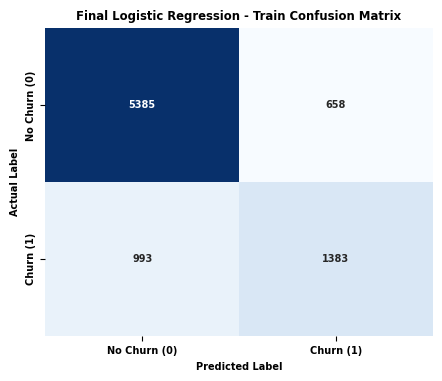

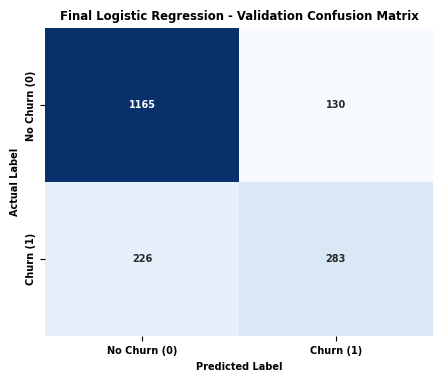

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ============================================================
# CONFUSION MATRIX FUNCTION
# ============================================================

def plot_statsmodels_confusion_matrix(
    model_result,
    X,
    y_true,
    title
):

    # Predicted probabilities
    probabilities = model_result.predict(X)

    # Convert probabilities to binary classes
    predictions = (probabilities >= 0.5).astype(int)

    # Create confusion matrix
    cm = confusion_matrix(y_true, predictions)

    # Plot
    plt.figure(figsize=(5, 4))

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['No Churn (0)', 'Churn (1)'],
        yticklabels=['No Churn (0)', 'Churn (1)',],
        annot_kws={'fontweight': 'bold'}
    )

    plt.ylabel('Actual Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')

    plt.title(title, fontweight='bold')

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.show()

# ============================================================
# TRAIN CONFUSION MATRIX
# ============================================================

plot_statsmodels_confusion_matrix(

    result_reduced,

    X_train_reduced_sm,

    y_train,

    title="Final Logistic Regression - Train Confusion Matrix"
)

# ============================================================
# VALIDATION CONFUSION MATRIX
# ============================================================

plot_statsmodels_confusion_matrix(

    result_reduced,

    X_val_reduced_sm,

    y_val,

    title="Final Logistic Regression - Validation Confusion Matrix"
)


*  The confusion matrix shows that the final Logistic Regression model correctly classified a large number of non-churn customers in both the training and validation datasets.
*  The model was also able to identify a reasonable number of churn customers; however, some churn cases were still misclassified as non-churn, contributing to comparatively lower Recall.
*  The train and validation confusion matrices follow a very similar pattern, indicating that the model generalizes well without severe overfitting.
*  False negatives are higher than false positives, suggesting that the model is relatively conservative while predicting churn customers.

### Improved SMOTE LR

In [ ]:
# ============================================================
# APPLY SMOTE ON FINAL IMPROVED LR FEATURES
# ============================================================

from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train_reduced,

    y_train
)

print("Original training shape:")
print(X_train_reduced.shape)

print("\nSMOTE training shape:")
print(X_train_smote.shape)

# ============================================================
# ADD CONSTANT
# ============================================================

X_train_smote_sm = sm.add_constant(
    X_train_smote
)

X_val_smote_sm = sm.add_constant(
    X_val_reduced
)

# ============================================================
# BUILD SMOTE LOGISTIC REGRESSION MODEL
# ============================================================

logit_smote = sm.Logit(

    y_train_smote,

    X_train_smote_sm
)

result_smote = logit_smote.fit()

# ============================================================
# MODEL SUMMARY
# ============================================================

print(result_smote.summary())

Original training shape:
(8419, 19)

SMOTE training shape:
(12086, 19)
Optimization terminated successfully.
         Current function value: 0.468707
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                12086
Model:                          Logit   Df Residuals:                    12066
Method:                           MLE   Df Model:                           19
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.3238
Time:                        18:50:59   Log-Likelihood:                -5664.8
converged:                       True   LL-Null:                       -8377.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

After applying smote, we can observe `SeniorCitizen` is not contributing significantly. However, the variable was retained due to its business relevance and demographic importance in customer churn analysis.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

# ============================================================
# PREDICTIONS
# ============================================================

# Train probabilities
y_train_prob_smote = result_smote.predict(
    X_train_smote_sm
)

# Validation probabilities
y_val_prob_smote = result_smote.predict(
    X_val_smote_sm
)

# Convert probabilities to binary predictions
y_train_pred_smote = (
    y_train_prob_smote >= 0.5
).astype(int)

y_val_pred_smote = (
    y_val_prob_smote >= 0.5
).astype(int)

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def get_metrics_dict(
    y_true,
    y_pred,
    y_prob
):

    return {

        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),

        'Precision': precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'Recall': recall_score(
            y_true,
            y_pred
        ),

        'F1-Score': f1_score(
            y_true,
            y_pred
        ),

        'ROC-AUC': roc_auc_score(
            y_true,
            y_prob
        )
    }

# ============================================================
# TRAIN METRICS
# ============================================================

train_metrics = get_metrics_dict(
    y_train_smote,
    y_train_pred_smote,
    y_train_prob_smote
)

# ============================================================
# VALIDATION METRICS
# ============================================================

val_metrics = get_metrics_dict(
    y_val,
    y_val_pred_smote,
    y_val_prob_smote
)

# ============================================================
# CREATE FINAL RESULTS TABLE
# ============================================================

smote_lr_results = pd.DataFrame(
    [train_metrics, val_metrics]
)

smote_lr_results.index = [
    'Train',
    'Validation'
]

# ============================================================
# DISPLAY RESULTS
# ============================================================

display(
    smote_lr_results.style.format(
        lambda x: f"{x * 100:.2f}%"
    )
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Train,78.05%,76.02%,81.95%,78.87%,85.90%
Validation,77.33%,57.04%,79.57%,66.45%,85.06%


*  After applying SMOTE on the improved Logistic Regression model, Recall increased significantly to ~80% on the validation set, indicating much better churn detection capability.
*  The model achieved a strong F1-score (66.45%), showing a better balance between Precision and Recall compared to the baseline Logistic Regression model.
*  Although Precision decreased on the validation set, the higher Recall suggests that the model is more effective in minimizing missed churn customers.
*  ROC-AUC remained stable at around 85%, indicating good class separation performance even after applying SMOTE.
*  The train and validation metrics are reasonably close, suggesting that the SMOTE-based improved Logistic Regression model generalizes well without severe overfitting.



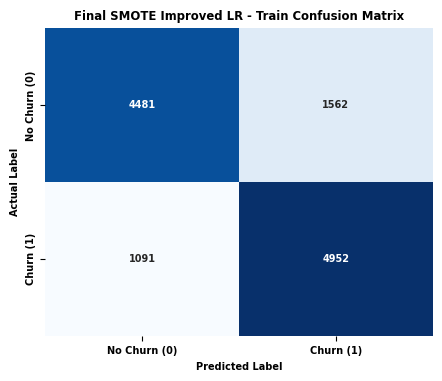

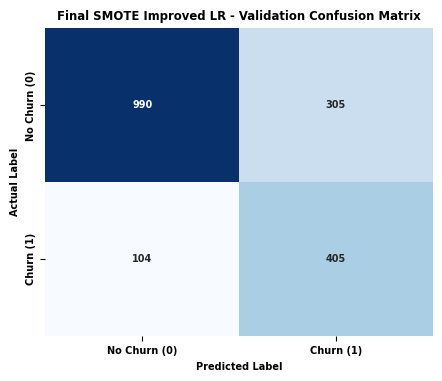

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ============================================================
# CONFUSION MATRIX FUNCTION
# ============================================================

def plot_direct_confusion_matrix(
    y_true,
    y_pred,
    title
):

    # Compute confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Plot
    plt.figure(figsize=(5, 4))

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['No Churn (0)', 'Churn (1)'],
        yticklabels=['No Churn (0)', 'Churn (1)',],
        annot_kws={'fontweight': 'bold'}
    )

    plt.ylabel('Actual Label', fontweight='bold')

    plt.xlabel('Predicted Label', fontweight='bold')

    plt.title(title, fontweight='bold')

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.show()

# ============================================================
# TRAIN CONFUSION MATRIX
# ============================================================

plot_direct_confusion_matrix(

    y_train_smote,

    y_train_pred_smote,

    title="Final SMOTE Improved LR - Train Confusion Matrix"
)

# ============================================================
# VALIDATION CONFUSION MATRIX
# ============================================================

plot_direct_confusion_matrix(

    y_val,

    y_val_pred_smote,

    title="Final SMOTE Improved LR - Validation Confusion Matrix"
)

*  After applying SMOTE, the model identified a significantly higher number of churn customers compared to the baseline Logistic Regression model, resulting in improved Recall performance.
*  The validation confusion matrix shows a reduction in false negatives, indicating that fewer actual churn customers were missed by the model.
*  However, the number of false positives increased after applying SMOTE, meaning that more non-churn customers were incorrectly predicted as churn customers.
*  The train and validation confusion matrices show similar prediction patterns, suggesting that the SMOTE-based improved Logistic Regression model generalizes reasonably well without severe overfitting.
*  Overall, the SMOTE-based model achieved a better balance between churn detection capability and overall model performance, making it more suitable for customer churn prediction where minimizing missed churners is important.

## Model Building - Original Data

**Let's define a function to output different metrics on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score
    auc_roc = roc_auc_score(target, pred)  # to compute AUC-ROC

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1, "AUC-ROC": auc_roc},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target, title="Confusion Matrix"):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    title: title of the plot (default is "Confusion Matrix")
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from xgboost import XGBClassifier

ratio = sum(y_train == 0) / sum(y_train == 1)

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, scale_pos_weight=ratio, eval_metric='logloss')))
# ============================================================
# TRAIN MODELS
# ============================================================

#
train_performance_results = {}
val_performance_results = {}

for name, model in models:
    model.fit(X_train, y_train)

    perf_df_train = model_performance_classification_sklearn(model, X_train, y_train)
    perf_df_val = model_performance_classification_sklearn(model, X_val, y_val)

    train_performance_results[name] = perf_df_train.iloc[0].to_dict()
    val_performance_results[name] = perf_df_val.iloc[0].to_dict()

print("--- All Model Performance on Training Data ---")
all_train_perf_df = pd.DataFrame(train_performance_results).T
display(all_train_perf_df.style.format("{:.2%}"))

print("\n--- All Model Performance on Validation Data ---")
all_val_perf_df = pd.DataFrame(val_performance_results).T
display(all_val_perf_df.style.format("{:.2%}"))

--- All Model Performance on Training Data ---


,Accuracy,Recall,Precision,F1,AUC-ROC
dtree,99.86%,100.00%,99.50%,99.75%,99.90%
Random forest,99.86%,100.00%,99.50%,99.75%,99.90%
GBM,81.97%,59.55%,71.75%,65.09%,75.17%
Adaboost,80.19%,56.48%,67.91%,61.67%,73.00%
XGBoost,91.55%,97.98%,77.83%,86.75%,93.50%



--- All Model Performance on Validation Data ---


,Accuracy,Recall,Precision,F1,AUC-ROC
dtree,74.06%,50.69%,54.32%,52.44%,66.97%
Random forest,79.32%,51.47%,67.53%,58.42%,70.87%
GBM,80.93%,55.80%,70.47%,62.28%,73.30%
Adaboost,80.93%,55.21%,70.78%,62.03%,73.12%
XGBoost,77.00%,67.39%,57.94%,62.31%,74.08%


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.2%}, Validation Score: {:.2%}, Difference: {:.2%}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

dtree: Training Score: 100.00%, Validation Score: 50.69%, Difference: 49.31%
Random forest: Training Score: 100.00%, Validation Score: 51.47%, Difference: 48.53%
GBM: Training Score: 59.55%, Validation Score: 55.80%, Difference: 3.76%
Adaboost: Training Score: 56.48%, Validation Score: 55.21%, Difference: 1.28%
XGBoost: Training Score: 97.98%, Validation Score: 67.39%, Difference: 30.59%


*  Decision Tree and Random Forest achieved extremely high training performance but showed a significant drop in validation metrics, indicating severe overfitting.
*  XGBoost achieved very high Recall on the training set; however, validation performance dropped noticeably, suggesting moderate overfitting.
*  Gradient Boosting and AdaBoost demonstrated more stable performance across training and validation datasets, indicating better generalization capability.
*  Among all models, Gradient Boosting achieved the best balance between Accuracy, Precision, Recall, and F1-score on the validation set.
*  AdaBoost produced performance very similar to Gradient Boosting, with slightly lower Recall and F1-score.
*  Ensemble boosting models (GBM and AdaBoost) generalized better compared to tree-based models like Decision Tree and Random Forest.
*  "Since Recall was the primary evaluation metric for churn prediction, XGBoost showed strong churn detection capability, but Gradient Boosting provided a more balanced overall performance across all evaluation metrics.

## Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of Certified 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 2376
Before Oversampling, counts of label 'Denied': 6043 

After Oversampling, counts of Certified 'Certified': 6043
After Oversampling, counts of label 'Denied': 6043 

After Oversampling, the shape of train_X: (12086, 22)
After Oversampling, the shape of train_y: (12086,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, eval_metric='logloss')))

oversampled_train_performance_results = {}
oversampled_val_performance_results = {}

for name, model in models:
    model.fit(X_train_over, y_train_over)

    perf_df_train_over = model_performance_classification_sklearn(model, X_train_over, y_train_over)
    perf_df_val_over = model_performance_classification_sklearn(model, X_val, y_val)

    oversampled_train_performance_results[name] = perf_df_train_over.iloc[0].to_dict()
    oversampled_val_performance_results[name] = perf_df_val_over.iloc[0].to_dict()

print("--- All Model Performance on Oversampled Training Data ---")
all_oversampled_train_perf_df = pd.DataFrame(oversampled_train_performance_results).T
display(all_oversampled_train_perf_df.style.format("{:.2%}"))

print("\n--- All Model Performance on Oversampled Validation Data ---")
all_oversampled_val_perf_df = pd.DataFrame(oversampled_val_performance_results).T
display(all_oversampled_val_perf_df.style.format("{:.2%}"))

--- All Model Performance on Oversampled Training Data ---


,Accuracy,Recall,Precision,F1,AUC-ROC
dtree,99.91%,99.82%,100.00%,99.91%,99.91%
Random forest,99.91%,99.97%,99.85%,99.91%,99.91%
GBM,84.83%,86.79%,83.52%,85.13%,84.83%
Adaboost,79.94%,84.33%,77.53%,80.79%,79.94%
XGBoost,93.21%,93.70%,92.79%,93.24%,93.21%



--- All Model Performance on Oversampled Validation Data ---


,Accuracy,Recall,Precision,F1,AUC-ROC
dtree,72.12%,54.22%,50.55%,52.32%,66.69%
Random forest,79.16%,60.12%,63.88%,61.94%,73.38%
GBM,79.93%,69.94%,63.01%,66.29%,76.90%
Adaboost,77.61%,77.80%,57.64%,66.22%,77.66%
XGBoost,77.88%,60.31%,60.91%,60.61%,72.55%


In [ ]:
print("\nTraining and Validation Performance Difference for oversampled data:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.2%}, Validation Score: {:.2%}, Difference: {:.2%}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference for oversampled data:

dtree: Training Score: 99.82%, Validation Score: 54.22%, Difference: 45.59%
Random forest: Training Score: 99.97%, Validation Score: 60.12%, Difference: 39.85%
GBM: Training Score: 86.79%, Validation Score: 69.94%, Difference: 16.85%
Adaboost: Training Score: 84.33%, Validation Score: 77.80%, Difference: 6.53%
XGBoost: Training Score: 93.70%, Validation Score: 60.31%, Difference: 33.38%


*  Decision Tree and Random Forest achieved near-perfect performance on the oversampled training data but showed a sharp decline on the validation set, indicating severe overfitting after applying SMOTE.
*  XGBoost also achieved very high training performance; however, its validation metrics dropped considerably, suggesting moderate overfitting.
*  Gradient Boosting and AdaBoost demonstrated comparatively better generalization, with more balanced training and validation performance.
*  AdaBoost achieved the highest Recall (77.80%) on the validation set, indicating strong churn detection capability after oversampling.
*  Gradient Boosting achieved the highest F1-score (66.29%) on the validation set, showing the best balance between Precision and Recall among the oversampled models.
*  Although oversampling improved Recall for most models, it also increased the risk of overfitting in highly complex models such as Decision Tree, Random Forest, and XGBoost.
*  Overall, Gradient Boosting and AdaBoost were the most stable and generalized models among the oversampled advanced models.

## Model Building - Undersampled Data

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 2376
Before Under Sampling, counts of label 'Denied': 6043 

After Under Sampling, counts of label 'Certified': 2376
After Under Sampling, counts of label 'Denied': 2376 

After Under Sampling, the shape of train_X: (4752, 22)
After Under Sampling, the shape of train_y: (4752,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, eval_metric='logloss')))

undersampled_train_performance_results = {}
undersampled_val_performance_results = {}

for name, model in models:
    model.fit(X_train_un, y_train_un)

    perf_df_train_un = model_performance_classification_sklearn(model, X_train_un, y_train_un)
    perf_df_val_un = model_performance_classification_sklearn(model, X_val, y_val)

    undersampled_train_performance_results[name] = perf_df_train_un.iloc[0].to_dict()
    undersampled_val_performance_results[name] = perf_df_val_un.iloc[0].to_dict()

print("--- All Model Performance on Undersampled Training Data ---")
all_undersampled_train_perf_df = pd.DataFrame(undersampled_train_performance_results).T
display(all_undersampled_train_perf_df.style.format("{:.2%}"))

print("\n--- All Model Performance on Undersampled Validation Data ---")
all_undersampled_val_perf_df = pd.DataFrame(undersampled_val_performance_results).T
display(all_undersampled_val_perf_df.style.format("{:.2%}"))

--- All Model Performance on Undersampled Training Data ---


,Accuracy,Recall,Precision,F1,AUC-ROC
dtree,99.85%,99.71%,100.00%,99.85%,99.85%
Random forest,99.85%,99.92%,99.79%,99.85%,99.85%
GBM,80.18%,83.25%,78.43%,80.77%,80.18%
Adaboost,77.67%,82.28%,75.34%,78.66%,77.67%
XGBoost,94.44%,96.72%,92.51%,94.57%,94.44%



--- All Model Performance on Undersampled Validation Data ---


,Accuracy,Recall,Precision,F1,AUC-ROC
dtree,69.51%,68.57%,47.23%,55.93%,69.22%
Random forest,76.61%,74.66%,56.46%,64.30%,76.02%
GBM,76.27%,78.19%,55.66%,65.03%,76.86%
Adaboost,75.78%,80.75%,54.80%,65.29%,77.28%
XGBoost,75.94%,77.80%,55.23%,64.60%,76.51%


In [ ]:
print("\nTraining and Validation Performance Difference of undersampled data:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.2%}, Validation Score: {:.2%}, Difference: {:.2%}".format(name, scores_train, scores_val, difference3))



Training and Validation Performance Difference of undersampled data:

dtree: Training Score: 99.71%, Validation Score: 68.57%, Difference: 31.14%
Random forest: Training Score: 99.92%, Validation Score: 74.66%, Difference: 25.26%
GBM: Training Score: 83.25%, Validation Score: 78.19%, Difference: 5.06%
Adaboost: Training Score: 82.28%, Validation Score: 80.75%, Difference: 1.53%
XGBoost: Training Score: 96.72%, Validation Score: 77.80%, Difference: 18.92%


*  Decision Tree and Random Forest achieved extremely high training performance but showed a substantial decline on the validation set, indicating severe overfitting after undersampling.
*  XGBoost achieved very high training Recall and F1-score; however, the noticeable drop in validation metrics suggests moderate overfitting.
*  Gradient Boosting and AdaBoost demonstrated comparatively better stability and generalization between training and validation datasets.
*  AdaBoost achieved the highest Recall (80.75%) on the validation set, indicating strong capability in identifying churn customers after undersampling.
*  Gradient Boosting achieved the highest F1-score (65.03%) among the undersampled models, indicating the best balance between Precision and Recall.
*  Undersampling improved Recall across most models; however, reducing majority class samples also led to lower Accuracy and Precision in several models.
*  Overall, Gradient Boosting and AdaBoost were the most balanced and generalized models among the undersampled advanced models.

# **Model Performance Improvement using Hyperparameter Tuning**

*  After building 19 models, models were shortlisted for hyperparameter tuning based on validation performance, particularly Recall and F1-score, since the dataset was imbalanced and minimizing false negatives was the primary business objective.

*  In addition to performance metrics, train-validation consistency was also considered to avoid selecting overfitted models.

*  Based on these criteria, the following models  were selected for further tuning as they demonstrated better generalization and balanced performance compared to other models.

      *  GBM + SMOTE
      *  AdaBoost + Undersample
      *  XGBoost + Original Data
      *  AdaBoost + SMOTE
      *  GBM + Undersample


## Tuning Gradient Boosting With Oversampled Data

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score, classification_report, confusion_matrix

# ============================================================
# 1. DEFINE THE CROSS-VALIDATION PIPELINE (Matching Your SMOTE Setup)
# ============================================================
tuning_pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)),
    ('gbm', GradientBoostingClassifier(random_state=1))
])

# ============================================================
# 2. DEFINE TUNING GRID
# ============================================================
param_grid = {
    'gbm__n_estimators': [50, 100, 150],
    'gbm__learning_rate': [0.01, 0.05, 0.1],
    'gbm__max_depth': [3, 5, 7],
    'gbm__min_samples_leaf': [5, 10, 20]
}

# ============================================================
# 3. SET UP GRID SEARCH OPTIMIZED FOR RECALL
# ============================================================
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 4. EXECUTE TUNING (Pass your original un-oversampled X_train)
# ============================================================
# Note: Pass X_train here because the imblearn Pipeline will handle
# oversampling correctly inside each cross-validation fold to prevent data leakage.
print("Starting Hyperparameter Tuning for SMOTE-GBM with all 22 features...")
grid_search.fit(X_train, y_train)

# ============================================================
# 5. EXTRACT BEST RESULTS
# ============================================================
print("\n=== Optimal Tuning Parameters Found ===")
print(grid_search.best_params_)
print(f"Best Cross-Validation Recall: {grid_search.best_score_ * 100:.2f}%")

best_gbm_model = grid_search.best_estimator_


Starting Hyperparameter Tuning for SMOTE-GBM with all 22 features...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== Optimal Tuning Parameters Found ===
{'gbm__learning_rate': 0.1, 'gbm__max_depth': 3, 'gbm__min_samples_leaf': 20, 'gbm__n_estimators': 50}
Best Cross-Validation Recall: 65.66%


In [ ]:
# ============================================================
# SAVE METRICS FOR COMPARISON USING YOUR CUSTOM FUNCTION
# ============================================================

# Calculate performance on original training data footprint
# (The best_gbm_model automatically handles the inner pipeline structure)
tuned_gbm_train = model_performance_classification_sklearn(
    best_gbm_model,
    X_train,
    y_train
)

# Calculate performance on validation footprint
tuned_gbm_val = model_performance_classification_sklearn(
    best_gbm_model,
    X_val,
    y_val
)

# Combine results into one clean summary table
tuned_gbm_results = pd.concat([tuned_gbm_train, tuned_gbm_val], axis=0)
tuned_gbm_results.index = ['Train', 'Validation']

# Display the final formatted comparison table
print("--- Tuned SMOTE-GBM Performance Matrix ---")
display(tuned_gbm_results.style.format(lambda x: f"{x * 100:.2f}%"))


--- Tuned SMOTE-GBM Performance Matrix ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,78.71%,76.14%,59.62%,66.88%,77.93%
Validation,79.05%,73.28%,60.65%,66.37%,77.30%


## Tuning AdaBoost With Undersampled Data

In [ ]:
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, accuracy_score

# ============================================================
# 1. DEFINE THE CROSS-VALIDATION PIPELINE (Prevents Data Leakage)
# ============================================================
under_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=1)),
    ('adaboost', AdaBoostClassifier(random_state=1))
])

# ============================================================
# 2. DEFINE THE TUNING GRID
# ============================================================
# We tune learning_rate to control the weight steps and n_estimators
# to prevent it from building too many trees and dropping precision.
param_grid = {
    'adaboost__n_estimators': [25, 50, 100, 150],
    'adaboost__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

# ============================================================
# 3. SET UP GRID SEARCH OPTIMIZED FOR F1-SCORE
# ============================================================
# We optimize for 'f1' instead of 'recall' here. This tells the engine
# to aggressively correct the low precision while keeping recall high.
grid_search_ada = GridSearchCV(
    estimator=under_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 4. EXECUTE TUNING (Using your full 22-feature X_train matrix)
# ============================================================
print("Starting Hyperparameter Tuning for Undersampled AdaBoost...")
grid_search_ada.fit(X_train, y_train)

# ============================================================
# 5. EXTRACT THE BEST ESTIMATOR
# ============================================================
print("\n=== Optimal AdaBoost Tuning Parameters Found ===")
print(grid_search_ada.best_params_)
print(f"Best Cross-Validation F1-Score: {grid_search_ada.best_score_ * 100:.2f}%")

best_ada_model = grid_search_ada.best_estimator_


Starting Hyperparameter Tuning for Undersampled AdaBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Optimal AdaBoost Tuning Parameters Found ===
{'adaboost__learning_rate': 0.5, 'adaboost__n_estimators': 150}
Best Cross-Validation F1-Score: 64.69%


In [ ]:
# ============================================================
# COMPUTE TRAINING AND VALIDATION METRICS
# ============================================================

# Calculate performance on your training matrix
tuned_ada_train = model_performance_classification_sklearn(
    best_ada_model,
    X_train,
    y_train
)

# Calculate performance on your validation matrix
tuned_ada_val = model_performance_classification_sklearn(
    best_ada_model,
    X_val,
    y_val
)

# Combine results into your standard presentation table
tuned_ada_results = pd.concat([tuned_ada_train, tuned_ada_val], axis=0)
tuned_ada_results.index = ['Train', 'Validation']

print("\n--- Tuned Undersampled AdaBoost Performance Matrix ---")
display(tuned_ada_results.style.format(lambda x: f"{x * 100:.2f}%"))



--- Tuned Undersampled AdaBoost Performance Matrix ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,75.20%,81.36%,54.02%,64.93%,77.07%
Validation,77.00%,80.35%,56.49%,66.34%,78.01%


### AdaBoost Undersample - Threshold Tuning

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 1. GENERATE CONTINUOUS PROBABILITIES FOR ADABOOST
# ============================================================
train_proba_ada = best_ada_model.predict_proba(X_train)[:, 1]
val_proba_ada   = best_ada_model.predict_proba(X_val)[:, 1]

# ============================================================
# 2. SCAN FOR THE THRESHOLD THAT ENFORCES PRECISION > 65%
# ============================================================
best_threshold_ada = 0.5
best_f1_ada = 0.0

for thresh in np.arange(0.01, 1.00, 0.01):
    temp_preds_ada = (val_proba_ada >= thresh).astype(int)  # ← validation!

    rec_ada = recall_score(y_val, temp_preds_ada, zero_division=0)
    prec_ada = precision_score(y_val, temp_preds_ada, zero_division=0)

    if prec_ada >= 0.50:  # Your precision constraint
        f1_ada = (2 * prec_ada * rec_ada) / (prec_ada + rec_ada)
        if f1_ada > best_f1_ada:
            best_f1_ada = f1_ada
            best_threshold_ada = thresh

print(f"Optimal AdaBoost Decision Threshold Located: {best_threshold_ada:.2f}")

# ============================================================
# 3. COMPUTE THE NEW PERFORMANCE MATRIX
# ============================================================
def get_thresholded_metrics_ada(y_true, probabilities, threshold):
    preds = (probabilities >= threshold).astype(int)
    acc = accuracy_score(y_true, preds)
    rec = recall_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds)
    auc = roc_auc_score(y_true, probabilities)
    return {"Accuracy": acc, "Recall": rec, "Precision": prec, "F1": f1,"AUC-ROC": auc}

tuned_thresh_train_ada = get_thresholded_metrics_ada(y_train, train_proba_ada, best_threshold_ada)
tuned_thresh_val_ada   = get_thresholded_metrics_ada(y_val, val_proba_ada, best_threshold_ada)

threshold_results_ada = pd.DataFrame([tuned_thresh_train_ada, tuned_thresh_val_ada])
threshold_results_ada.index = ['Train', 'Validation']

print("\n--- Tuned AdaBoost Performance Matrix (Optimized Threshold) ---")
display(threshold_results_ada.style.format(lambda x: f"{x * 100:.2f}%"))


Optimal AdaBoost Decision Threshold Located: 0.51

--- Tuned AdaBoost Performance Matrix (Optimized Threshold) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,76.21%,80.22%,55.42%,65.55%,84.98%
Validation,77.77%,78.98%,57.76%,66.72%,85.35%


## Tuning XGBoost With Original Data

In [ ]:
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# ============================================================
# 1. CALCULATE CLASS WEIGHT RATIO FOR XGBOOST
# ============================================================
# Instead of hard-coding 3, we calculate the exact negative-to-positive ratio
ratio = sum(y_train == 0) / sum(y_train == 1)

# ============================================================
# 2. DEFINE THE TUNING PIPELINE
# ============================================================
tuning_pipeline_xgb = Pipeline([
    ('xgb', XGBClassifier(
        random_state=1,
        scale_pos_weight=ratio,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# ============================================================
# 3. DEFINE THE HYPERPARAMETER GRID
# ============================================================
# We tune structural depth and regularization parameters (reg_alpha, reg_lambda)
# to minimize false alarms and stabilize precision.
param_grid_xgb = {
    'xgb__n_estimators': [50, 100],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 4, 5],
    'xgb__reg_alpha': [0, 0.1, 1],      # L1 Regularization (Lasso)
    'xgb__reg_lambda': [1, 5, 10]       # L2 Regularization (Ridge)
}

# ============================================================
# 4. SET UP GRID SEARCH OPTIMIZED FOR F1-SCORE
# ============================================================
# Optimizing for 'f1' tells the engine to maximize both metrics simultaneously
grid_search_xgb = GridSearchCV(
    estimator=tuning_pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 5. EXECUTE TUNING (Using your full 22-feature X_train matrix)
# ============================================================
print("Starting Hyperparameter Tuning for XGBoost...")
grid_search_xgb.fit(X_train, y_train)

# ============================================================
# 6. EXTRACT THE BEST ESTIMATOR
# ============================================================
print("\n=== Optimal XGBoost Tuning Parameters Found ===")
print(grid_search_xgb.best_params_)
print(f"Best Cross-Validation F1-Score: {grid_search_xgb.best_score_ * 100:.2f}%")

best_xgb_model = grid_search_xgb.best_estimator_


Starting Hyperparameter Tuning for XGBoost...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

=== Optimal XGBoost Tuning Parameters Found ===
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 4, 'xgb__n_estimators': 100, 'xgb__reg_alpha': 1, 'xgb__reg_lambda': 10}
Best Cross-Validation F1-Score: 65.80%


In [ ]:
# ============================================================
# COMPUTE TRAINING AND VALIDATION METRICS FOR XGBOOST
# ============================================================

# Calculate performance on your full 22-feature training matrix
tuned_xgb_train = model_performance_classification_sklearn(
    best_xgb_model,
    X_train,
    y_train
)

# Calculate performance on your full 22-feature validation matrix
tuned_xgb_val = model_performance_classification_sklearn(
    best_xgb_model,
    X_val,
    y_val
)

# Combine results into your standard presentation table
tuned_xgb_results = pd.concat([tuned_xgb_train, tuned_xgb_val], axis=0)
tuned_xgb_results.index = ['Train', 'Validation']

print("\n--- Tuned XGBoost Performance Matrix ---")
display(tuned_xgb_results.style.format(lambda x: f"{x * 100:.2f}%"))



--- Tuned XGBoost Performance Matrix ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,78.51%,83.25%,58.37%,68.62%,79.95%
Validation,77.55%,77.80%,57.56%,66.17%,77.63%


### XGBoost Original - Threshold Tuning

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

# ============================================================
# 1. EXTRACT RAW CONTINUOUS PROBABILITIES FROM TUNED XGBOOST
# ============================================================
# We use predict_proba to pull the raw confidence values
val_proba_xgb = best_xgb_model.predict_proba(X_val)[:, 1]

# ============================================================
# 2. RUN STEPPED SCAN ACROSS THRESHOLDS
# ============================================================
xgb_scan = []

for thresh in np.arange(0.50, 0.66, 0.01):
    # Apply custom threshold boundary
    val_preds_xgb = (val_proba_xgb >= thresh).astype(int)

    rec_x = recall_score(y_val, val_preds_xgb, zero_division=0)
    prec_x = precision_score(y_val, val_preds_xgb, zero_division=0)
    f1_x = f1_score(y_val, val_preds_xgb, zero_division=0)
    acc_x = accuracy_score(y_val, val_preds_xgb)

    xgb_scan.append({
        "Threshold": f"{thresh:.2f}",
        "Accuracy": f"{acc_x * 100:.2f}%",
        "Recall": f"{rec_x * 100:.2f}%",
        "Precision": f"{prec_x * 100:.2f}%",
        "F1": f"{f1_x * 100:.2f}%"
    })

display(pd.DataFrame(xgb_scan))


,Threshold,Accuracy,Recall,Precision,F1
0,0.50,77.55%,77.80%,57.56%,66.17%
1,0.51,78.22%,77.60%,58.61%,66.78%
2,0.52,78.60%,76.23%,59.42%,66.78%
3,0.53,78.94%,75.25%,60.13%,66.84%
4,0.54,79.21%,75.25%,60.60%,67.13%
5,0.55,79.55%,74.85%,61.25%,67.37%
6,0.56,79.71%,73.67%,61.78%,67.20%
7,0.57,79.71%,72.50%,62.02%,66.85%
8,0.58,80.16%,72.10%,62.95%,67.22%
9,0.59,80.04%,70.73%,63.05%,66.67%


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# ============================================================
# 1. GENERATE RAW CONTINUOUS PROBABILITIES
# ============================================================
train_proba_final = best_xgb_model.predict_proba(X_train)[:, 1]
val_proba_final   = best_xgb_model.predict_proba(X_val)[:, 1]

# ============================================================
# 2. APPLY THE TARGET OPTIMIZED THRESHOLD (0.55)
# ============================================================
TARGET_THRESHOLD = 0.55

# Convert probabilities to binary 0/1 classes using the 0.55 cutoff
y_train_pred_final = (train_proba_final >= TARGET_THRESHOLD).astype(int)
y_val_pred_final   = (val_proba_final >= TARGET_THRESHOLD).astype(int)

# ============================================================
# 3. COMPUTE THE NEW OPTIMIZED PERFORMANCE MATRIX
# ============================================================
def calculate_metrics_at_threshold(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    return {"Accuracy": acc, "Recall": rec, "Precision": prec, "F1": f1, "AUC-ROC": auc}

# Generate rows for your summary table
final_xgb_train = calculate_metrics_at_threshold(y_train, y_train_pred_final, train_proba_final) # Fixed: Pass train_proba_final
final_xgb_val   = calculate_metrics_at_threshold(y_val, y_val_pred_final, val_proba_final)     # Fixed: Pass val_proba_final

# Combine into your standard DataFrame structure
final_xgb_results = pd.DataFrame([final_xgb_train, final_xgb_val])
final_xgb_results.index = ['Train', 'Validation']

# ============================================================
# 4. DISPLAY FINAL FORMATTED MATRIX
# ============================================================
print(f"--- Tuned XGBoost Performance Matrix (Threshold Applied: {TARGET_THRESHOLD}) ---")
display(final_xgb_results.style.format(lambda x: f"{x * 100:.2f}%"))

--- Tuned XGBoost Performance Matrix (Threshold Applied: 0.55) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,79.94%,78.45%,61.30%,68.82%,88.13%
Validation,79.55%,74.85%,61.25%,67.37%,85.59%


## Tuning AdaBoost with Oversampled Data

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# ============================================================
# 1. DEFINE THE CROSS-VALIDATION PIPELINE
# ============================================================
tuning_pipeline_ada_smote = Pipeline([
    ('smote', SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)),
    ('adaboost', AdaBoostClassifier(random_state=1))
])

# ============================================================
# 2. DEFINE THE HYPERPARAMETER GRID
# ============================================================
param_grid_ada_smote = {
    'adaboost__n_estimators': [50, 100, 150, 200],
    'adaboost__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

# ============================================================
# 3. SET UP GRID SEARCH OPTIMIZED FOR F1
# ============================================================
grid_search_ada_smote = GridSearchCV(
    estimator=tuning_pipeline_ada_smote,
    param_grid=param_grid_ada_smote,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 4. EXECUTE TUNING (Pass original un-oversampled X_train)
# ============================================================
print("Starting Hyperparameter Tuning for SMOTE AdaBoost...")
grid_search_ada_smote.fit(X_train, y_train)

# ============================================================
# 5. EXTRACT BEST RESULTS
# ============================================================
print("\n=== Optimal AdaBoost SMOTE Tuning Parameters Found ===")
print(grid_search_ada_smote.best_params_)
print(f"Best Cross-Validation F1-Score: {grid_search_ada_smote.best_score_ * 100:.2f}%")

best_ada_smote_model = grid_search_ada_smote.best_estimator_

# ============================================================
# 6. EVALUATE ON TRAIN AND VALIDATION
# ============================================================
tuned_ada_smote_train = model_performance_classification_sklearn(
    best_ada_smote_model, X_train, y_train
)
tuned_ada_smote_val = model_performance_classification_sklearn(
    best_ada_smote_model, X_val, y_val
)

tuned_ada_smote_results = pd.concat([tuned_ada_smote_train, tuned_ada_smote_val], axis=0)
tuned_ada_smote_results.index = ['Train', 'Validation']

print("\n--- Tuned SMOTE AdaBoost Performance Matrix ---")
display(tuned_ada_smote_results.style.format(lambda x: f"{x * 100:.2f}%"))

Starting Hyperparameter Tuning for SMOTE AdaBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Optimal AdaBoost SMOTE Tuning Parameters Found ===
{'adaboost__learning_rate': 1.0, 'adaboost__n_estimators': 150}
Best Cross-Validation F1-Score: 65.52%

--- Tuned SMOTE AdaBoost Performance Matrix ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,77.17%,78.28%,56.95%,65.93%,77.51%
Validation,78.33%,77.80%,58.75%,66.95%,78.17%


## Tuning GradientBoosting With Undersampled Data

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# ============================================================
# 1. DEFINE THE CROSS-VALIDATION PIPELINE
# ============================================================
tuning_pipeline_gbm_under = Pipeline([
    ('rus', RandomUnderSampler(random_state=1)),
    ('gbm', GradientBoostingClassifier(random_state=1))
])

# ============================================================
# 2. DEFINE THE HYPERPARAMETER GRID
# ============================================================
param_grid_gbm_under = {
    'gbm__n_estimators': [50, 100, 150],
    'gbm__learning_rate': [0.01, 0.05, 0.1],
    'gbm__max_depth': [3, 5, 7],
    'gbm__min_samples_leaf': [5, 10, 20]
}

# ============================================================
# 3. SET UP GRID SEARCH OPTIMIZED FOR F1
# ============================================================
grid_search_gbm_under = GridSearchCV(
    estimator=tuning_pipeline_gbm_under,
    param_grid=param_grid_gbm_under,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 4. EXECUTE TUNING (Pass original X_train — pipeline handles undersampling)
# ============================================================
print("Starting Hyperparameter Tuning for Undersampled GBM...")
grid_search_gbm_under.fit(X_train, y_train)

# ============================================================
# 5. EXTRACT BEST RESULTS
# ============================================================
print("\n=== Optimal GBM Undersampled Tuning Parameters Found ===")
print(grid_search_gbm_under.best_params_)
print(f"Best Cross-Validation F1-Score: {grid_search_gbm_under.best_score_ * 100:.2f}%")

best_gbm_under_model = grid_search_gbm_under.best_estimator_

# ============================================================
# 6. EVALUATE ON TRAIN AND VALIDATION
# ============================================================
tuned_gbm_under_train = model_performance_classification_sklearn(
    best_gbm_under_model, X_train, y_train
)
tuned_gbm_under_val = model_performance_classification_sklearn(
    best_gbm_under_model, X_val, y_val
)

tuned_gbm_under_results = pd.concat([tuned_gbm_under_train, tuned_gbm_under_val], axis=0)
tuned_gbm_under_results.index = ['Train', 'Validation']

print("\n--- Tuned Undersampled GBM Performance Matrix ---")
display(tuned_gbm_under_results.style.format(lambda x: f"{x * 100:.2f}%"))

Starting Hyperparameter Tuning for Undersampled GBM...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== Optimal GBM Undersampled Tuning Parameters Found ===
{'gbm__learning_rate': 0.1, 'gbm__max_depth': 3, 'gbm__min_samples_leaf': 20, 'gbm__n_estimators': 100}
Best Cross-Validation F1-Score: 65.18%

--- Tuned Undersampled GBM Performance Matrix ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,77.12%,82.70%,56.47%,67.11%,78.82%
Validation,76.83%,78.59%,56.42%,65.68%,77.36%


### GBM Undersample - Threshold Tuning

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

# ============================================================
# 1. GENERATE PROBABILITIES
# ============================================================
val_proba_gbm_under = best_gbm_under_model.predict_proba(X_val)[:, 1]

# ============================================================
# 2. SCAN THRESHOLDS ON VALIDATION DATA
# ============================================================
gbm_under_scan = []

for thresh in np.arange(0.30, 0.70, 0.01):
    val_preds = (val_proba_gbm_under >= thresh).astype(int)

    rec = recall_score(y_val, val_preds, zero_division=0)
    prec = precision_score(y_val, val_preds, zero_division=0)
    f1 = f1_score(y_val, val_preds, zero_division=0)
    acc = accuracy_score(y_val, val_preds)

    gbm_under_scan.append({
        "Threshold": f"{thresh:.2f}",
        "Accuracy": f"{acc * 100:.2f}%",
        "Recall": f"{rec * 100:.2f}%",
        "Precision": f"{prec * 100:.2f}%",
        "F1": f"{f1 * 100:.2f}%"
    })

display(pd.DataFrame(gbm_under_scan))

,Threshold,Accuracy,Recall,Precision,F1
0,0.30,68.29%,90.37%,46.80%,61.66%
1,0.31,69.12%,89.78%,47.51%,62.13%
2,0.32,69.51%,89.00%,47.84%,62.23%
3,0.33,69.79%,89.00%,48.09%,62.44%
4,0.34,70.57%,88.80%,48.81%,63.00%
5,0.35,71.06%,88.41%,49.29%,63.29%
6,0.36,71.67%,87.23%,49.89%,63.47%
7,0.37,71.95%,86.64%,50.17%,63.54%
8,0.38,72.34%,85.85%,50.58%,63.66%
9,0.39,72.67%,85.27%,50.94%,63.78%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score

# ============================================================
# 1. GENERATE PROBABILITIES FOR TRAIN AND VALIDATION
# ============================================================
train_proba_gbm_under = best_gbm_under_model.predict_proba(X_train)[:, 1]
val_proba_gbm_under = best_gbm_under_model.predict_proba(X_val)[:, 1]

# ============================================================
# 2. APPLY THRESHOLD 0.55
# ============================================================
THRESHOLD = 0.55

y_train_pred_gbm = (train_proba_gbm_under >= THRESHOLD).astype(int)
y_val_pred_gbm = (val_proba_gbm_under >= THRESHOLD).astype(int)

# ============================================================
# 3. COMPUTE METRICS
# ============================================================
def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_proba)
    }

train_metrics = get_metrics(y_train, y_train_pred_gbm, train_proba_gbm_under)
val_metrics = get_metrics(y_val, y_val_pred_gbm, val_proba_gbm_under)

results = pd.DataFrame([train_metrics, val_metrics])
results.index = ['Train', 'Validation']

print(f"--- GBM Undersampled (Threshold: {THRESHOLD}) ---")
display(results.style.format(lambda x: f"{x * 100:.2f}%"))

--- GBM Undersampled (Threshold: 0.55) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,78.79%,78.62%,59.38%,67.66%,86.80%
Validation,78.88%,75.83%,59.94%,66.96%,85.35%


# **Model Comparison and Final Model Selection**

## Training Performance comparison

In [ ]:
import pandas as pd

# ============================================================
# GENERATE PROBABILITIES FOR ALL 5 MODELS
# ============================================================

# AdaBoost Undersampled (Threshold: 0.51)
train_proba_ada_under = best_ada_model.predict_proba(X_train)[:, 1]

# XGBoost Original (Threshold: 0.55)
train_proba_xgb = best_xgb_model.predict_proba(X_train)[:, 1]

# AdaBoost SMOTE (Threshold: 0.50)
train_proba_ada_smote = best_ada_smote_model.predict_proba(X_train)[:, 1]

# GBM Undersampled (Threshold: 0.55)
train_proba_gbm_under = best_gbm_under_model.predict_proba(X_train)[:, 1]

# GBM SMOTE (Threshold: 0.50)
train_proba_gbm_smote = best_gbm_model.predict_proba(X_train)[:, 1]

# ============================================================
# APPLY THRESHOLDS
# ============================================================

y_train_pred_ada_under  = (train_proba_ada_under >= 0.51).astype(int)
y_train_pred_xgb        = (train_proba_xgb >= 0.55).astype(int)
y_train_pred_ada_smote  = (train_proba_ada_smote >= 0.50).astype(int)
y_train_pred_gbm_under  = (train_proba_gbm_under >= 0.55).astype(int)
y_train_pred_gbm_smote  = (train_proba_gbm_smote >= 0.50).astype(int)

# ============================================================
# METRICS FUNCTION
# ============================================================

def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred),
        "AUC-ROC":   roc_auc_score(y_true, y_proba)
    }

# ============================================================
# COLLECT TRAINING PERFORMANCE
# ============================================================

comparison_data_train = {

    "AdaBoost Undersampled (Threshold: 0.51)": get_metrics(
        y_train, y_train_pred_ada_under, train_proba_ada_under
    ),

    "XGBoost Original (Threshold: 0.55)": get_metrics(
        y_train, y_train_pred_xgb, train_proba_xgb
    ),

    "AdaBoost SMOTE (Threshold: 0.50)": get_metrics(
        y_train, y_train_pred_ada_smote, train_proba_ada_smote
    ),

    "GBM Undersampled (Threshold: 0.55)": get_metrics(
        y_train, y_train_pred_gbm_under, train_proba_gbm_under
    ),

    "GBM SMOTE (Threshold: 0.50)": get_metrics(
        y_train, y_train_pred_gbm_smote, train_proba_gbm_smote
    )
}

# ============================================================
# CREATE AND DISPLAY DATAFRAME
# ============================================================

models_train_comp_df = pd.DataFrame(comparison_data_train).T

print("--- Training Performance Comparison (Top 5 Tuned Models) ---")
display(models_train_comp_df.style.format("{:.2%}"))

--- Training Performance Comparison (Top 5 Tuned Models) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
AdaBoost Undersampled (Threshold: 0.51),76.21%,80.22%,55.42%,65.55%,84.98%
XGBoost Original (Threshold: 0.55),79.94%,78.45%,61.30%,68.82%,88.13%
AdaBoost SMOTE (Threshold: 0.50),77.17%,78.28%,56.95%,65.93%,85.09%
GBM Undersampled (Threshold: 0.55),78.79%,78.62%,59.38%,67.66%,86.80%
GBM SMOTE (Threshold: 0.50),78.71%,76.14%,59.62%,66.88%,85.70%


## Validation Performance Comparison

In [ ]:
import pandas as pd

# ============================================================
# GENERATE PROBABILITIES FOR ALL 5 MODELS
# ============================================================

# AdaBoost Undersampled (Threshold: 0.51)
val_proba_ada_under = best_ada_model.predict_proba(X_val)[:, 1]

# XGBoost Original (Threshold: 0.55)
val_proba_xgb = best_xgb_model.predict_proba(X_val)[:, 1]

# AdaBoost SMOTE (Threshold: 0.50)
val_proba_ada_smote = best_ada_smote_model.predict_proba(X_val)[:, 1]

# GBM Undersampled (Threshold: 0.55)
val_proba_gbm_under = best_gbm_under_model.predict_proba(X_val)[:, 1]

# GBM SMOTE (Threshold: 0.50)
val_proba_gbm_smote = best_gbm_model.predict_proba(X_val)[:, 1]

# ============================================================
# APPLY THRESHOLDS
# ============================================================

y_val_pred_ada_under  = (val_proba_ada_under >= 0.51).astype(int)
y_val_pred_xgb        = (val_proba_xgb >= 0.55).astype(int)
y_val_pred_ada_smote  = (val_proba_ada_smote >= 0.50).astype(int)
y_val_pred_gbm_under  = (val_proba_gbm_under >= 0.55).astype(int)
y_val_pred_gbm_smote  = (val_proba_gbm_smote >= 0.50).astype(int)

# ============================================================
# COLLECT VALIDATION PERFORMANCE
# ============================================================

comparison_data_val = {

    "AdaBoost Undersampled (Threshold: 0.51)": get_metrics(
        y_val, y_val_pred_ada_under, val_proba_ada_under
    ),

    "XGBoost Original (Threshold: 0.55)": get_metrics(
        y_val, y_val_pred_xgb, val_proba_xgb
    ),

    "AdaBoost SMOTE (Threshold: 0.50)": get_metrics(
        y_val, y_val_pred_ada_smote, val_proba_ada_smote
    ),

    "GBM Undersampled (Threshold: 0.55)": get_metrics(
        y_val, y_val_pred_gbm_under, val_proba_gbm_under
    ),

    "GBM SMOTE (Threshold: 0.50)": get_metrics(
        y_val, y_val_pred_gbm_smote, val_proba_gbm_smote
    )
}

# ============================================================
# CREATE AND DISPLAY DATAFRAME
# ============================================================

models_val_comp_df = pd.DataFrame(comparison_data_val).T

print("--- Validation Performance Comparison (Top 5 Tuned Models) ---")
display(models_val_comp_df.style.format("{:.2%}"))

--- Validation Performance Comparison (Top 5 Tuned Models) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
AdaBoost Undersampled (Threshold: 0.51),77.77%,78.98%,57.76%,66.72%,85.35%
XGBoost Original (Threshold: 0.55),79.55%,74.85%,61.25%,67.37%,85.59%
AdaBoost SMOTE (Threshold: 0.50),78.33%,77.80%,58.75%,66.95%,85.15%
GBM Undersampled (Threshold: 0.55),78.88%,75.83%,59.94%,66.96%,85.35%
GBM SMOTE (Threshold: 0.50),79.05%,73.28%,60.65%,66.37%,84.96%


## Test Performance Comparison

In [ ]:
# ============================================================
# GENERATE PROBABILITIES FOR ALL 5 MODELS ON TEST DATA
# ============================================================

test_proba_ada_under = best_ada_model.predict_proba(X_test)[:, 1]
test_proba_xgb       = best_xgb_model.predict_proba(X_test)[:, 1]
test_proba_ada_smote = best_ada_smote_model.predict_proba(X_test)[:, 1]
test_proba_gbm_under = best_gbm_under_model.predict_proba(X_test)[:, 1]
test_proba_gbm_smote = best_gbm_model.predict_proba(X_test)[:, 1]

# ============================================================
# APPLY THRESHOLDS
# ============================================================

y_test_pred_ada_under  = (test_proba_ada_under >= 0.51).astype(int)
y_test_pred_xgb        = (test_proba_xgb >= 0.55).astype(int)
y_test_pred_ada_smote  = (test_proba_ada_smote >= 0.50).astype(int)
y_test_pred_gbm_under  = (test_proba_gbm_under >= 0.55).astype(int)
y_test_pred_gbm_smote  = (test_proba_gbm_smote >= 0.50).astype(int)

# ============================================================
# COLLECT TEST PERFORMANCE
# ============================================================

comparison_data_test = {

    "AdaBoost Undersampled (Threshold: 0.51)": get_metrics(
        y_test, y_test_pred_ada_under, test_proba_ada_under
    ),

    "XGBoost Original (Threshold: 0.55)": get_metrics(
        y_test, y_test_pred_xgb, test_proba_xgb
    ),

    "AdaBoost SMOTE (Threshold: 0.50)": get_metrics(
        y_test, y_test_pred_ada_smote, test_proba_ada_smote
    ),

    "GBM Undersampled (Threshold: 0.55)": get_metrics(
        y_test, y_test_pred_gbm_under, test_proba_gbm_under
    ),

    "GBM SMOTE (Threshold: 0.50)": get_metrics(
        y_test, y_test_pred_gbm_smote, test_proba_gbm_smote
    )
}

# ============================================================
# CREATE AND DISPLAY DATAFRAME
# ============================================================

models_test_comp_df = pd.DataFrame(comparison_data_test).T

print("--- Test Performance Comparison (Top 5 Tuned Models) ---")
display(models_test_comp_df.style.format("{:.2%}"))

--- Test Performance Comparison (Top 5 Tuned Models) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
AdaBoost Undersampled (Threshold: 0.51),75.79%,78.00%,54.99%,64.50%,84.50%
XGBoost Original (Threshold: 0.55),77.51%,72.30%,58.14%,64.45%,84.76%
AdaBoost SMOTE (Threshold: 0.50),76.18%,74.85%,55.78%,63.93%,84.57%
GBM Undersampled (Threshold: 0.55),76.73%,73.28%,56.77%,63.98%,84.65%
GBM SMOTE (Threshold: 0.50),76.95%,72.10%,57.25%,63.83%,84.34%


In [ ]:
import pandas as pd

# ============================================================
# GENERATE PROBABILITIES FOR BOTH FINAL MODELS
# ============================================================

# AdaBoost Undersampled (Threshold: 0.51)
train_proba_ada = best_ada_model.predict_proba(X_train)[:, 1]
val_proba_ada   = best_ada_model.predict_proba(X_val)[:, 1]
test_proba_ada  = best_ada_model.predict_proba(X_test)[:, 1]

# XGBoost Original (Threshold: 0.55)
train_proba_xgb = best_xgb_model.predict_proba(X_train)[:, 1]
val_proba_xgb   = best_xgb_model.predict_proba(X_val)[:, 1]
test_proba_xgb  = best_xgb_model.predict_proba(X_test)[:, 1]

# ============================================================
# APPLY THRESHOLDS
# ============================================================

y_train_pred_ada = (train_proba_ada >= 0.51).astype(int)
y_val_pred_ada   = (val_proba_ada >= 0.51).astype(int)
y_test_pred_ada  = (test_proba_ada >= 0.51).astype(int)

y_train_pred_xgb = (train_proba_xgb >= 0.55).astype(int)
y_val_pred_xgb   = (val_proba_xgb >= 0.55).astype(int)
y_test_pred_xgb  = (test_proba_xgb >= 0.55).astype(int)

# ============================================================
# ADABOOST UNDERSAMPLED - TRAIN, VAL, TEST
# ============================================================

ada_train = get_metrics(y_train, y_train_pred_ada, train_proba_ada)
ada_val   = get_metrics(y_val, y_val_pred_ada, val_proba_ada)
ada_test  = get_metrics(y_test, y_test_pred_ada, test_proba_ada)

ada_results = pd.DataFrame([ada_train, ada_val, ada_test])
ada_results.index = ['Train', 'Validation', 'Test']

print("--- AdaBoost Undersampled (Threshold: 0.51) ---")
display(ada_results.style.format("{:.2%}"))

# ============================================================
# XGBOOST ORIGINAL - TRAIN, VAL, TEST
# ============================================================

xgb_train = get_metrics(y_train, y_train_pred_xgb, train_proba_xgb)
xgb_val   = get_metrics(y_val, y_val_pred_xgb, val_proba_xgb)
xgb_test  = get_metrics(y_test, y_test_pred_xgb, test_proba_xgb)

xgb_results = pd.DataFrame([xgb_train, xgb_val, xgb_test])
xgb_results.index = ['Train', 'Validation', 'Test']

print("\n--- XGBoost Original (Threshold: 0.55) ---")
display(xgb_results.style.format("{:.2%}"))

--- AdaBoost Undersampled (Threshold: 0.51) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,76.21%,80.22%,55.42%,65.55%,84.98%
Validation,77.77%,78.98%,57.76%,66.72%,85.35%
Test,75.79%,78.00%,54.99%,64.50%,84.50%



--- XGBoost Original (Threshold: 0.55) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
Train,79.94%,78.45%,61.30%,68.82%,88.13%
Validation,79.55%,74.85%,61.25%,67.37%,85.59%
Test,77.51%,72.30%,58.14%,64.45%,84.76%


Two final models are recommended:

*  Among the tuned models, AdaBoost with Undersampling and threshold optimization (0.51) was identified as the best-performing model because it achieved the highest Recall (78.00%) along with a strong F1-score (64.50%), making it highly effective in identifying potential churn customers while maintaining balanced overall performance.

*  XGBoost Original with threshold optimization (0.55) was selected as the second-best model due to its strong consistency and balanced performance across all evaluation metrics. The model achieved the highest Precision (58.14%) and ROC-AUC (84.76%) among the shortlisted models, indicating better class separation capability and more stable generalization performance.

## Confusion Matrix

MODEL 1: AdaBoost Undersampled (Threshold: 0.51)


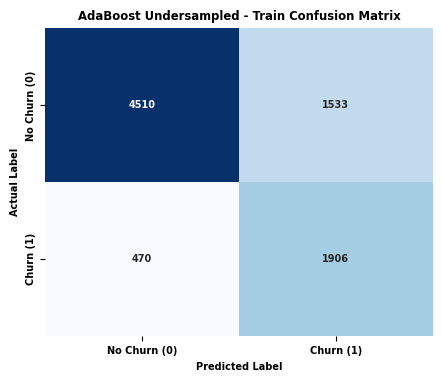

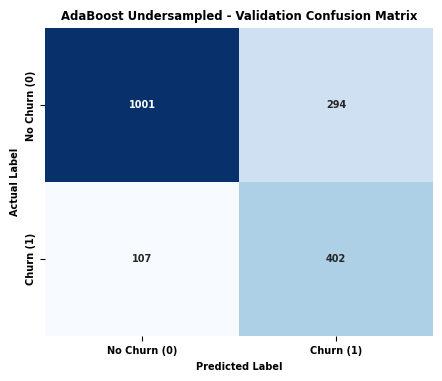

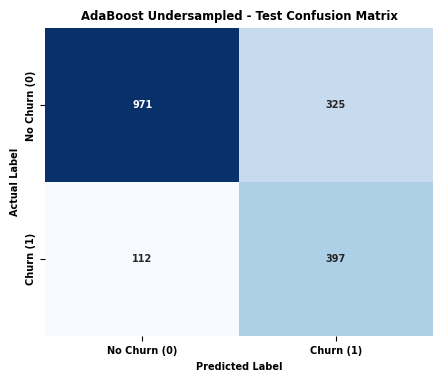


--- AdaBoost Undersampled - Test Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1296
       Churn       0.55      0.78      0.65       509

    accuracy                           0.76      1805
   macro avg       0.72      0.76      0.73      1805
weighted avg       0.80      0.76      0.77      1805

MODEL 2: XGBoost Original (Threshold: 0.55)


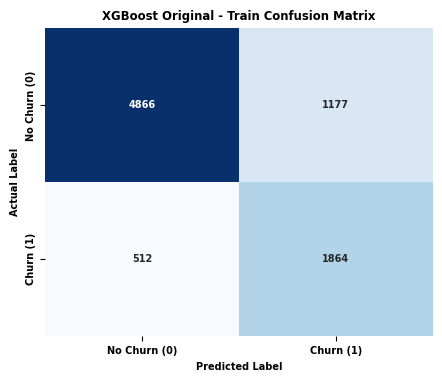

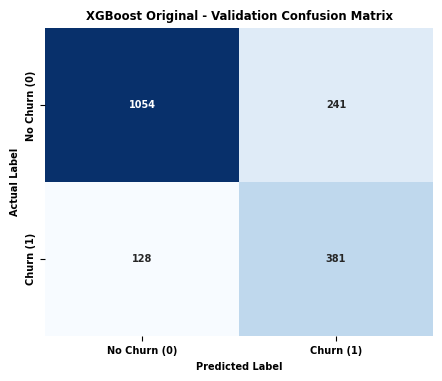

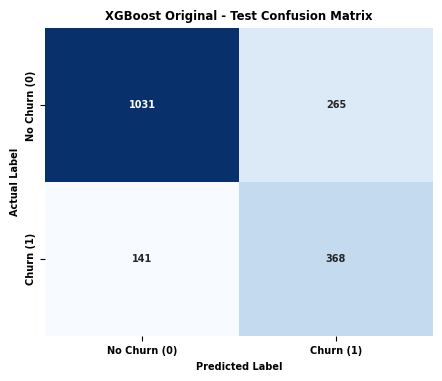


--- XGBoost Original - Test Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1296
       Churn       0.58      0.72      0.64       509

    accuracy                           0.78      1805
   macro avg       0.73      0.76      0.74      1805
weighted avg       0.80      0.78      0.78      1805


--- Final Model Comparison (Test Set) ---


,Accuracy,Recall,Precision,F1,AUC-ROC
AdaBoost Undersampled (0.51),0.758,0.780,0.550,0.645,0.845
XGBoost Original (0.55),0.775,0.723,0.581,0.644,0.848


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# 1. CONFUSION MATRIX FUNCTION
# ============================================================

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['No Churn (0)', 'Churn (1)'] ,
        yticklabels=['No Churn (0)', 'Churn (1)'] ,
        annot_kws={'fontweight': 'bold'}
    )

    plt.ylabel('Actual Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.title(title, fontweight='bold')

    # Make tick labels bold
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.show()

# ============================================================
# 2. ADABOOST UNDERSAMPLED - CONFUSION MATRICES
# ============================================================

print("=" * 60)
print("MODEL 1: AdaBoost Undersampled (Threshold: 0.51)")
print("=" * 60)

# Train
plot_confusion_matrix(
    y_train,
    y_train_pred_ada_under,
    title="AdaBoost Undersampled - Train Confusion Matrix"
)

# Validation
plot_confusion_matrix(
    y_val,
    y_val_pred_ada_under,
    title="AdaBoost Undersampled - Validation Confusion Matrix"
)

# Test
plot_confusion_matrix(
    y_test,
    y_test_pred_ada_under,
    title="AdaBoost Undersampled - Test Confusion Matrix"
)

# Classification Report
print("\n--- AdaBoost Undersampled - Test Classification Report ---")
print(classification_report(
    y_test,
    y_test_pred_ada_under,
    target_names=['No Churn', 'Churn']
))

# ============================================================
# 3. XGBOOST ORIGINAL - CONFUSION MATRICES
# ============================================================

print("=" * 60)
print("MODEL 2: XGBoost Original (Threshold: 0.55)")
print("=" * 60)

# Train
plot_confusion_matrix(
    y_train,
    y_train_pred_xgb,
    title="XGBoost Original - Train Confusion Matrix"
)

# Validation
plot_confusion_matrix(
    y_val,
    y_val_pred_xgb,
    title="XGBoost Original - Validation Confusion Matrix"
)

# Test
plot_confusion_matrix(
    y_test,
    y_test_pred_xgb,
    title="XGBoost Original - Test Confusion Matrix"
)

# Classification Report
print("\n--- XGBoost Original - Test Classification Report ---")
print(classification_report(
    y_test,
    y_test_pred_xgb,
    target_names=['No Churn', 'Churn']
))

# ============================================================
# 4. FINAL SIDE BY SIDE COMPARISON
# ============================================================

final_comparison = {
    "AdaBoost Undersampled (0.51)": get_metrics(
        y_test, y_test_pred_ada_under, test_proba_ada_under
    ),
    "XGBoost Original (0.55)": get_metrics(
        y_test, y_test_pred_xgb, test_proba_xgb
    )
}

final_comp_df = pd.DataFrame(final_comparison).T

print("\n--- Final Model Comparison (Test Set) ---")
display(final_comp_df.style.format("{:.3f}").set_table_styles([
    {"selector": "th", "props": "font-weight: bold;"},
    {"selector": "td", "props": "font-weight: bold;"}
]))


## Feature Importance

--- AdaBoost Undersampled Feature Importance ---


,Feature,Importance
0,tenure,0.214156
1,MonthlyCharges,0.175489
2,Contract_Month-to-month,0.146328
3,TotalCharges,0.120224
4,TechSupport_Yes,0.074554
5,PaymentMethod_Electronic check,0.068134
6,InternetService_Fiber optic,0.065553
7,Dependents_Yes,0.052480
8,Contract_One year,0.039183
9,OnlineSecurity_Yes,0.023117


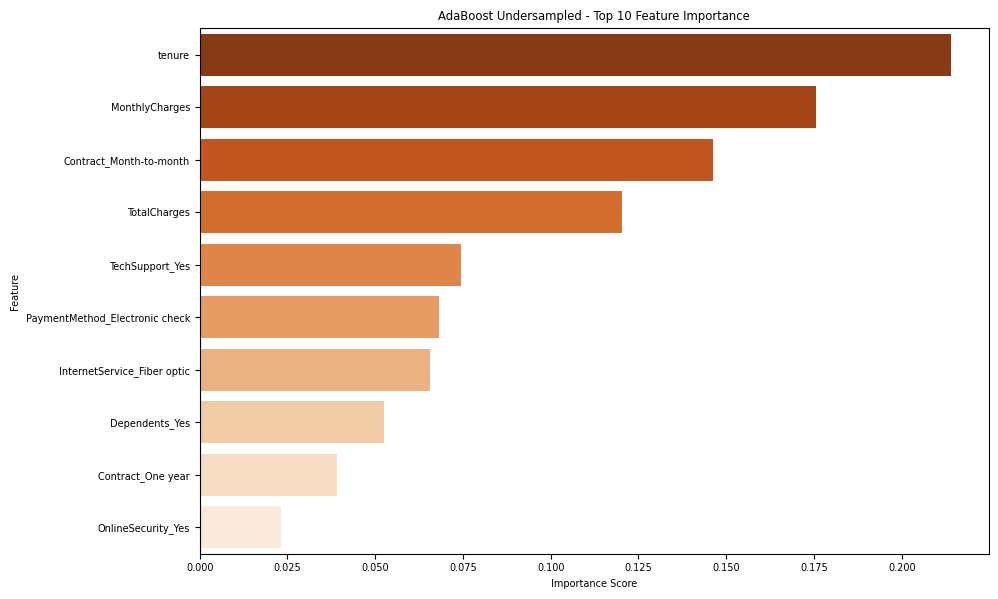

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# ADABOOST FEATURE IMPORTANCE
# ============================================================

# Extract feature importance from pipeline
ada_importance = best_ada_model.named_steps['adaboost'].feature_importances_

# Get feature names
feature_names = X_train.columns.tolist()

# Create dataframe
ada_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': ada_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("--- AdaBoost Undersampled Feature Importance ---")
display(ada_importance_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ada_importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='Oranges_r'
)
plt.title('AdaBoost Undersampled - Top 10 Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

--- XGBoost Feature Importance ---


,Feature,Importance
0,Contract_Month-to-month,0.599835
1,InternetService_Fiber optic,0.091263
2,PaymentMethod_Electronic check,0.050809
3,InternetService_DSL,0.046264
4,TechSupport_Yes,0.027843
5,Contract_One year,0.025079
6,OnlineSecurity_Yes,0.019767
7,tenure,0.018091
8,Dependents_Yes,0.015328
9,TotalCharges,0.011387


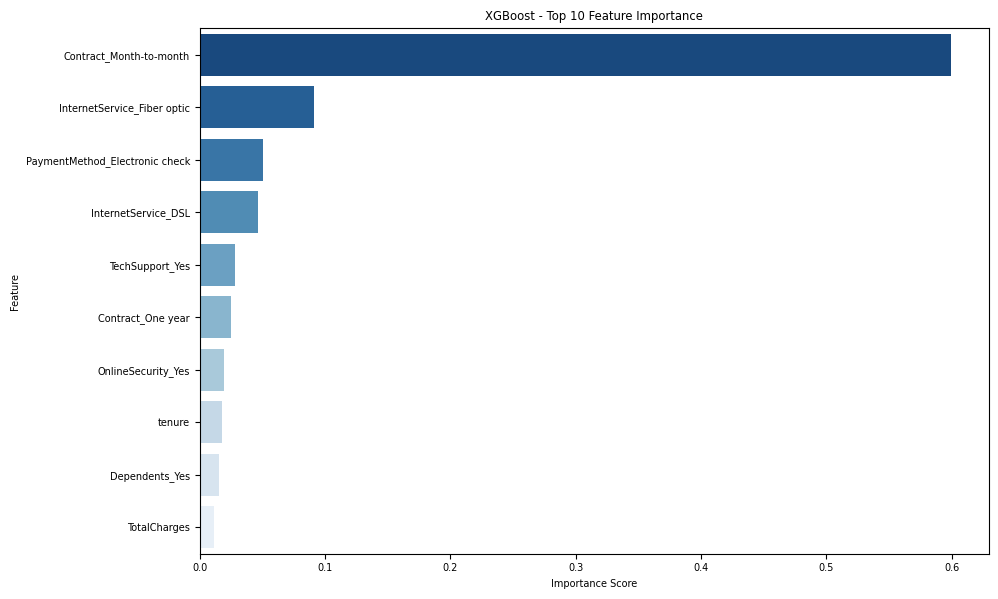

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

# Extract feature importance from pipeline
xgb_importance = best_xgb_model.named_steps['xgb'].feature_importances_

# Get feature names
feature_names = X_train.columns.tolist()

# Create dataframe
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("--- XGBoost Feature Importance ---")
display(xgb_importance_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='Blues_r'
)
plt.title('XGBoost - Top 10 Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

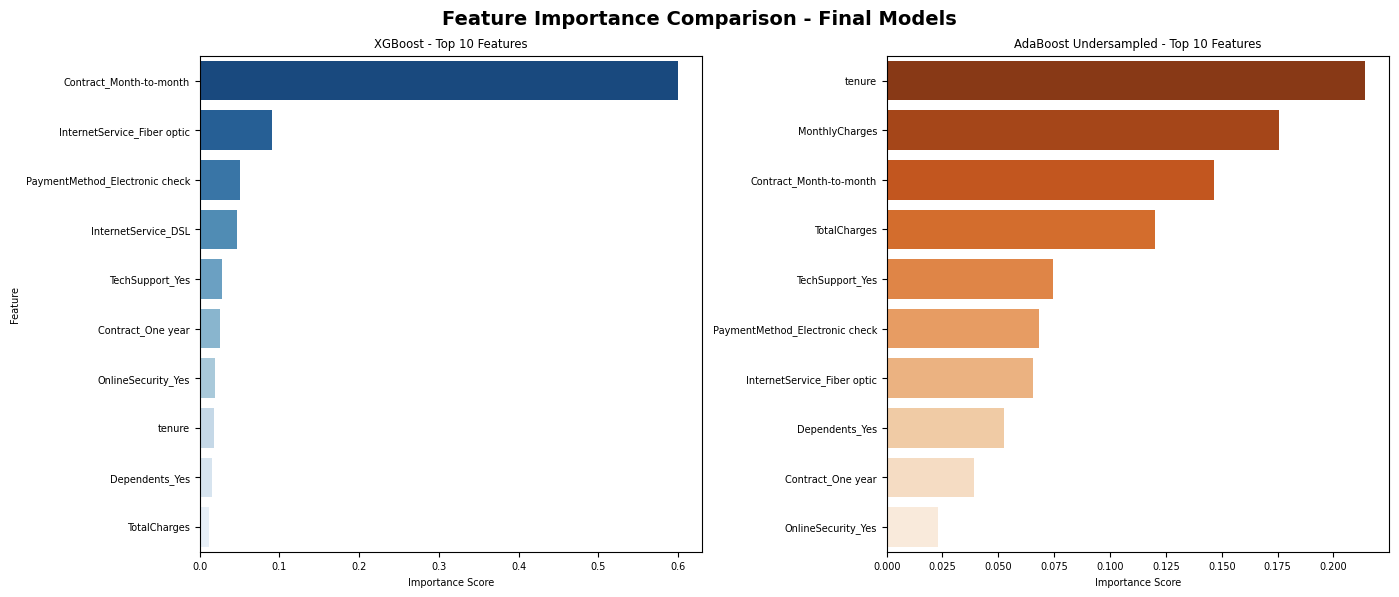

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# COMBINED FEATURE IMPORTANCE COMPARISON
# ============================================================

# Add model labels
xgb_importance_df['Model'] = 'XGBoost'
ada_importance_df['Model'] = 'AdaBoost Undersampled'

# Get top 10 from each
top10_xgb = xgb_importance_df.head(10)
top10_ada = ada_importance_df.head(10)

# Plot side by side
plt.figure(figsize=(14, 6))

# XGBoost
plt.subplot(1, 2, 1)
sns.barplot(
    data=top10_xgb,
    x='Importance',
    y='Feature',
    palette='Blues_r'
)
plt.title('XGBoost - Top 10 Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# AdaBoost
plt.subplot(1, 2, 2)
sns.barplot(
    data=top10_ada,
    x='Importance',
    y='Feature',
    palette='Oranges_r'
)
plt.title('AdaBoost Undersampled - Top 10 Features')
plt.xlabel('Importance Score')
plt.ylabel('')

plt.suptitle(
    'Feature Importance Comparison - Final Models',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

## ROC/Precision-Recall Curve

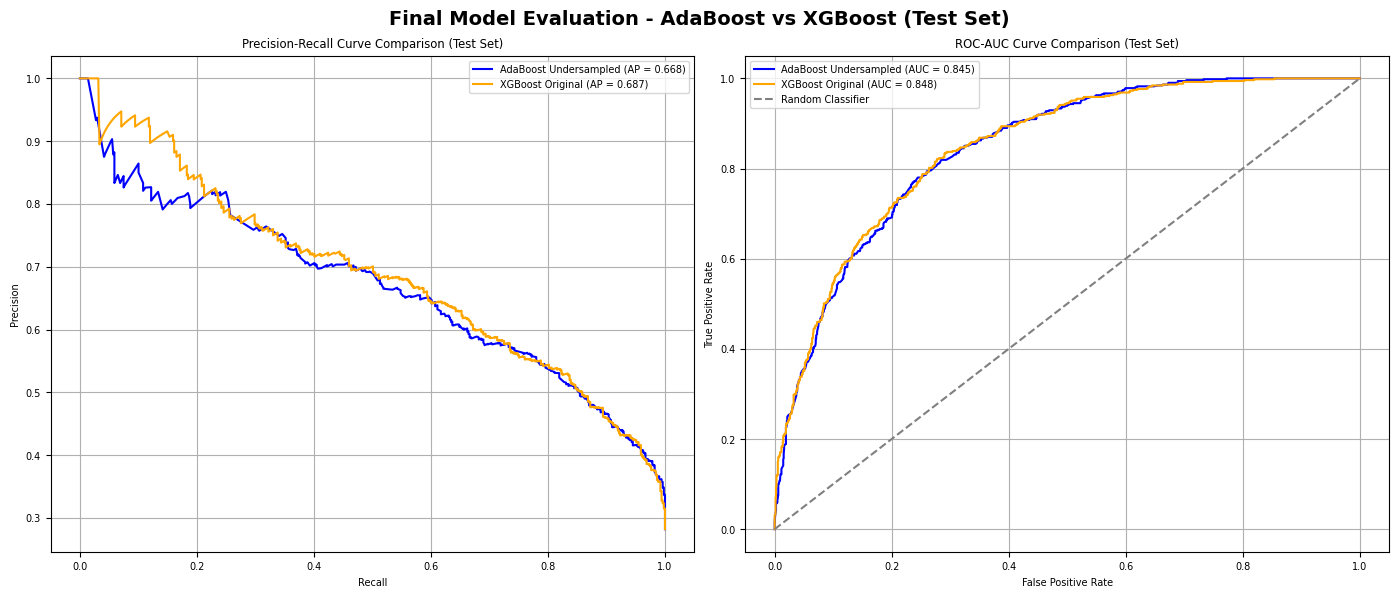

--- Curve Summary ---
AdaBoost Undersampled → AP: 0.668 | AUC-ROC: 0.845
XGBoost Original      → AP: 0.687 | AUC-ROC: 0.848


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)

# ============================================================
# 1. GENERATE PROBABILITIES
# ============================================================

test_proba_ada_under = best_ada_model.predict_proba(X_test)[:, 1]
test_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# ============================================================
# 2. PRECISION-RECALL CURVE DATA
# ============================================================

# AdaBoost
ada_precision, ada_recall, _ = precision_recall_curve(
    y_test, test_proba_ada_under
)
ada_ap = average_precision_score(y_test, test_proba_ada_under)

# XGBoost
xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test, test_proba_xgb
)
xgb_ap = average_precision_score(y_test, test_proba_xgb)

# ============================================================
# 3. ROC CURVE DATA
# ============================================================

# AdaBoost
ada_fpr, ada_tpr, _ = roc_curve(y_test, test_proba_ada_under)
ada_auc = roc_auc_score(y_test, test_proba_ada_under)

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, test_proba_xgb)
xgb_auc = roc_auc_score(y_test, test_proba_xgb)

# ============================================================
# 4. PLOT BOTH CURVES SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Precision-Recall Curve ---
axes[0].plot(
    ada_recall, ada_precision,
    color='blue',
    label=f'AdaBoost Undersampled (AP = {ada_ap:.3f})'
)
axes[0].plot(
    xgb_recall, xgb_precision,
    color='orange',
    label=f'XGBoost Original (AP = {xgb_ap:.3f})'
)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve Comparison (Test Set)')
axes[0].legend()
axes[0].grid(True)

# --- ROC-AUC Curve ---
axes[1].plot(
    ada_fpr, ada_tpr,
    color='blue',
    label=f'AdaBoost Undersampled (AUC = {ada_auc:.3f})'
)
axes[1].plot(
    xgb_fpr, xgb_tpr,
    color='orange',
    label=f'XGBoost Original (AUC = {xgb_auc:.3f})'
)
axes[1].plot(
    [0, 1], [0, 1],
    color='gray',
    linestyle='--',
    label='Random Classifier'
)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve Comparison (Test Set)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(
    'Final Model Evaluation - AdaBoost vs XGBoost (Test Set)',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# ============================================================
# 5. PRINT SUMMARY
# ============================================================

print("--- Curve Summary ---")
print(f"AdaBoost Undersampled → AP: {ada_ap:.3f} | AUC-ROC: {ada_auc:.3f}")
print(f"XGBoost Original      → AP: {xgb_ap:.3f} | AUC-ROC: {xgb_auc:.3f}")

**Precision-Recall Curve:**

*  XGBoost maintains higher precision across most recall levels
*  AdaBoost curve is jagged/unstable at low recall levels — sign of less confident probability estimates
*  XGBoost curve is smoother — more reliable predictions
*  Both converge at higher recall levels


**ROC-AUC Curve:**

*  Both models are far above the random classifier baseline
*  Curves are nearly identical — both models discriminate equally well
*  XGBoost marginally better



# **Business Insights and Recommendation**

---

**Insight 1: Contract Type is the Strongest Churn Predictor**
- Month-to-month customers churn significantly more than annual customers
- XGBoost assigns it the highest importance score (0.60)

- **Recommendation:** Launch a *'Lock-in & Save'* campaign offering discounted rates or free service upgrades in exchange for switching to 1-year or 2-year contracts

---

**Insight 2: Tenure — New Customers Churn the Most**
- AdaBoost identifies tenure as the #1 predictor (importance: 0.21)
- Customers with short tenure have significantly higher churn rates

- **Recommendation:** Implement a structured 6-month onboarding program with loyalty rewards at 3 and 6 months to improve early retention

---

**Insight 3: High Monthly Charges Drive Churn**
- Churners pay ~$80/month vs ~$65/month for non-churners
- MonthlyCharges is the 2nd most important feature in AdaBoost

- **Recommendation:** Introduce tiered loyalty discounts for customers paying above $75/month for 6+ months — automatic bill credits or service upgrades

---

**Insight 4: Fiber Optic Internet Customers Churn More**
- Fiber optic ranks 2nd in XGBoost and 7th in AdaBoost
- Despite being a premium service, churn rate remains high

- **Recommendation:** Conduct a service quality audit and proactively offer speed upgrades or price locks to retain premium customers

---

**Insight 5: Lack of Tech Support Increases Churn**
- TechSupport_Yes ranks 5th in both final models consistently
- Technical frustration is a key silent churn driver

- **Recommendation:** Bundle complimentary tech support trials for customers identified as high churn risk by the model

---

**Insight 6: Electronic Check Payment Users Churn the Most**
- Electronic check users have the highest churn rate (49.1%)
- Automatic payment methods correlate with much lower churn (14-16%)

- **Recommendation:** Incentivize electronic check users to switch to automatic bank transfer or credit card payments through bill discounts

---

**Insight 7: Senior Citizens Are a High-Risk Segment**
- Senior citizens churn at 42.4% vs 26.3% for non-seniors — nearly double

- **Recommendation:** Design a dedicated senior retention program with simplified billing, dedicated support lines, and special pricing plans

---

**Insight 8: Online Security Reduces Churn**
- Customers without online security are more likely to churn
- Consistent signal across both final models

- **Recommendation:** Offer free online security trials to customers identified as high churn risk by the model

**Conclusion:**

Two complementary models were developed to address AlphaCom's churn problem. AdaBoost Undersampled maximizes churn detection (recall: 78%) while XGBoost provides the most balanced and reliable predictions (AUC-ROC: 0.848, AP: 0.687). Together, these models enable AlphaCom to proactively identify at-risk customers, design targeted retention strategies, and ultimately safeguard revenue and strengthen competitive position.



In [ ]:
# Step 1: Find your notebook name
import os
notebook_name = os.popen('ls /content/*.ipynb').read().strip()
print("Notebook found:", notebook_name)

Notebook found: 


In [ ]:
# Step 2: Convert to HTML
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Alphacom - Capstone Project.ipynb"
print("Done! Check Files panel on the left")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Alphacom - Capstone Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 29 image(s).
[NbConvertApp] Writing 3450272 bytes to /content/drive/MyDrive/Colab Notebooks/Alphacom - Capstone Project.html
Done! Check Files panel on the left
